In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.preprocessing.data_preprocessing import EQDataLoader, DataPreprocessor, ZScoreStandard, Data_Sets, ExperimentalDataPreprocessor
from main_new import DataFile


dL = EQDataLoader()
# final_df = dL.data_f
# x_t, y_mag = DataFile()._load_final_data()
x_t = DataFile()._load_final_data()
# final_df.head(5)

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


### Data Viz

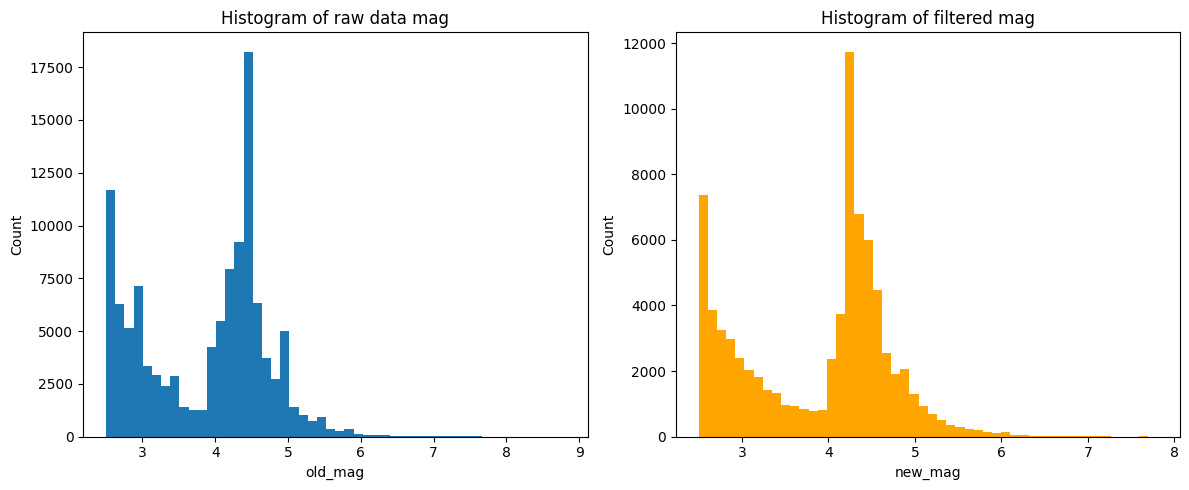

In [24]:
mag = final_df['mag']

import matplotlib.pyplot as plt
# %matplotlib.inline

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(mag, 50)
axes[0].set_title('Histogram of raw data mag')
axes[0].set_xlabel('old_mag')
axes[0].set_ylabel('Count')

axes[1].hist(y_mag, 50, color='orange')
axes[1].set_title('Histogram of filtered mag')
axes[1].set_xlabel('new_mag')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [28]:
mean_mag = mag.mean()
std_mag = mag.std()
skew_mag = mag.skew()

print("Mean of mag: \n", "Raw", mean_mag, "\nFiltered: ", y_mag.mean())
print("Standard deviation of mag: \n", "Raw", std_mag, "\nFiltered: ", y_mag.std())
print("Skewness of mag: \n", "Raw",  skew_mag, "\nFiltered: ", y_mag.skew())

Mean of mag: 
 Raw 3.8741288920333923 
Filtered:  3.8946980506100646
Standard deviation of mag: 
 Raw 0.8550519974846447 
Filtered:  0.8472400044132108
Skewness of mag: 
 Raw -0.1291784238088796 
Filtered:  -0.1689340977415185


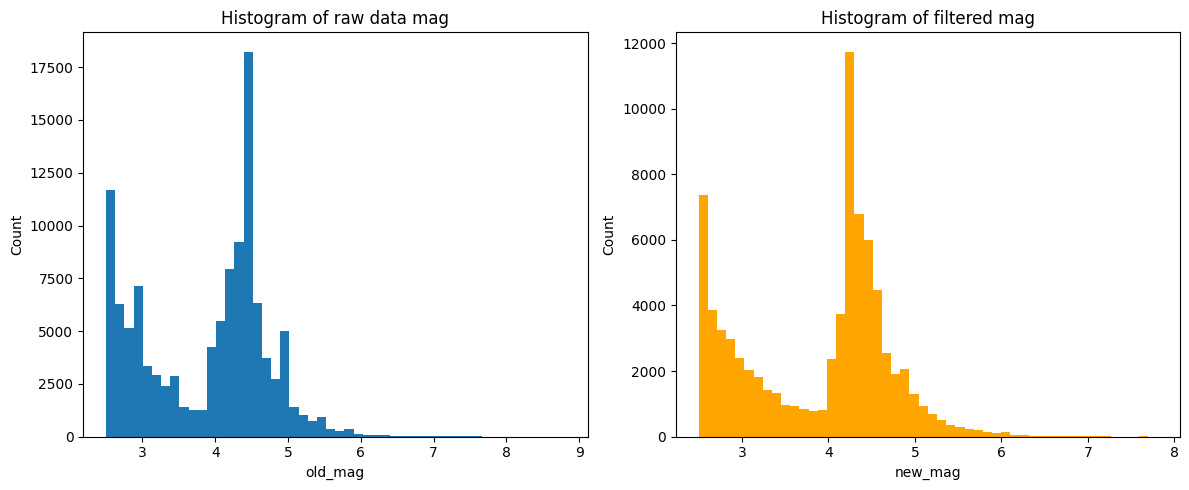

In [29]:
import scipy
import math

mag2 = mag.copy()
mag2 = mag.apply(lambda x: math.sqrt(x))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(mag, 50)
axes[0].set_title('Histogram of raw data mag')
axes[0].set_xlabel('old_mag')
axes[0].set_ylabel('Count')

axes[1].hist(y_mag, 50, color='orange')
axes[1].set_title('Histogram of filtered mag')
axes[1].set_xlabel('new_mag')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'elevation'}>,
        <Axes: title={'center': 'gap'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'rms'}>,
        <Axes: title={'center': 'dmin_km'}>,
        <Axes: title={'center': 'mb'}>, <Axes: title={'center': 'ml'}>],
       [<Axes: title={'center': 'md'}>, <Axes: title={'center': 'mww'}>,
        <Axes: title={'center': 'mwr'}>, <Axes: title={'center': 'mw'}>],
       [<Axes: title={'center': 'mb_lg'}>,
        <Axes: title={'center': 'others'}>, <Axes: >, <Axes: >]],
      dtype=object)

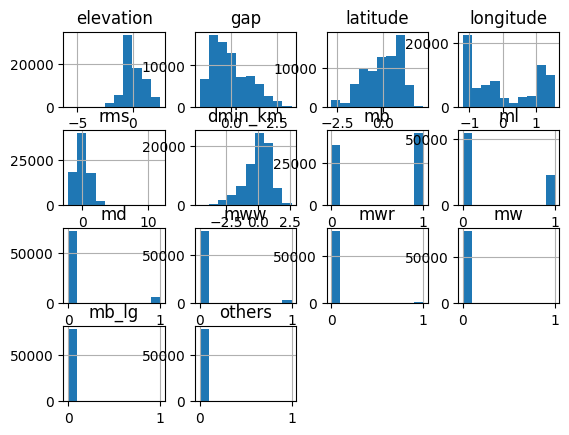

In [34]:
x_t.hist()

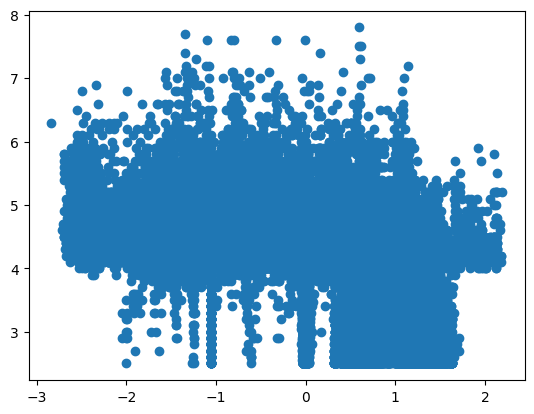

In [39]:
plt.scatter(x=x_t['latitude'], y=y_mag)

In [2]:
x_t

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [3]:
for i in x_t.columns:
    print(f"{i} --> {x_t[i].skew()}")

dmin --> 4.741359657422391
elevation --> 3.321751453939877
gap --> 0.6323492767797373
latitude --> -0.5565485026108005
longitude --> 0.252843661761184
mag --> -0.1415358328598202


TypeError: could not convert string to float: 'ml'

In [60]:
fin_new_df.isna().sum()

mag            0
time           0
detail         0
nst        12944
dmin        8689
rms            1
gap         6185
magType        0
dtype: int64

In [2]:
x_t.isna().sum()

dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64

In [6]:
x_t.describe()

,dmin,elevation,gap,latitude,longitude,mag,rms
count,110693.000000,113392.000000,113138.000000,113392.000000,113392.000000,113392.000000,113392.000000
mean,2.431387,62.220001,128.331855,20.755448,-21.192242,3.882270,0.594131
std,3.969295,111.326063,69.719825,30.981053,130.761183,0.852578,0.279791
min,0.000000,-3.740000,8.000000,-84.493200,-179.999700,2.500000,0.000000
25%,0.456000,10.000000,73.000000,-4.509950,-152.388750,3.000000,0.400000
50%,1.236000,17.080000,117.000000,24.125300,-66.956167,4.200000,0.600000
75%,2.806000,60.472250,176.000000,51.172350,126.651000,4.500000,0.780000
max,62.558000,681.238000,358.180000,87.081500,179.999400,8.800000,3.730000


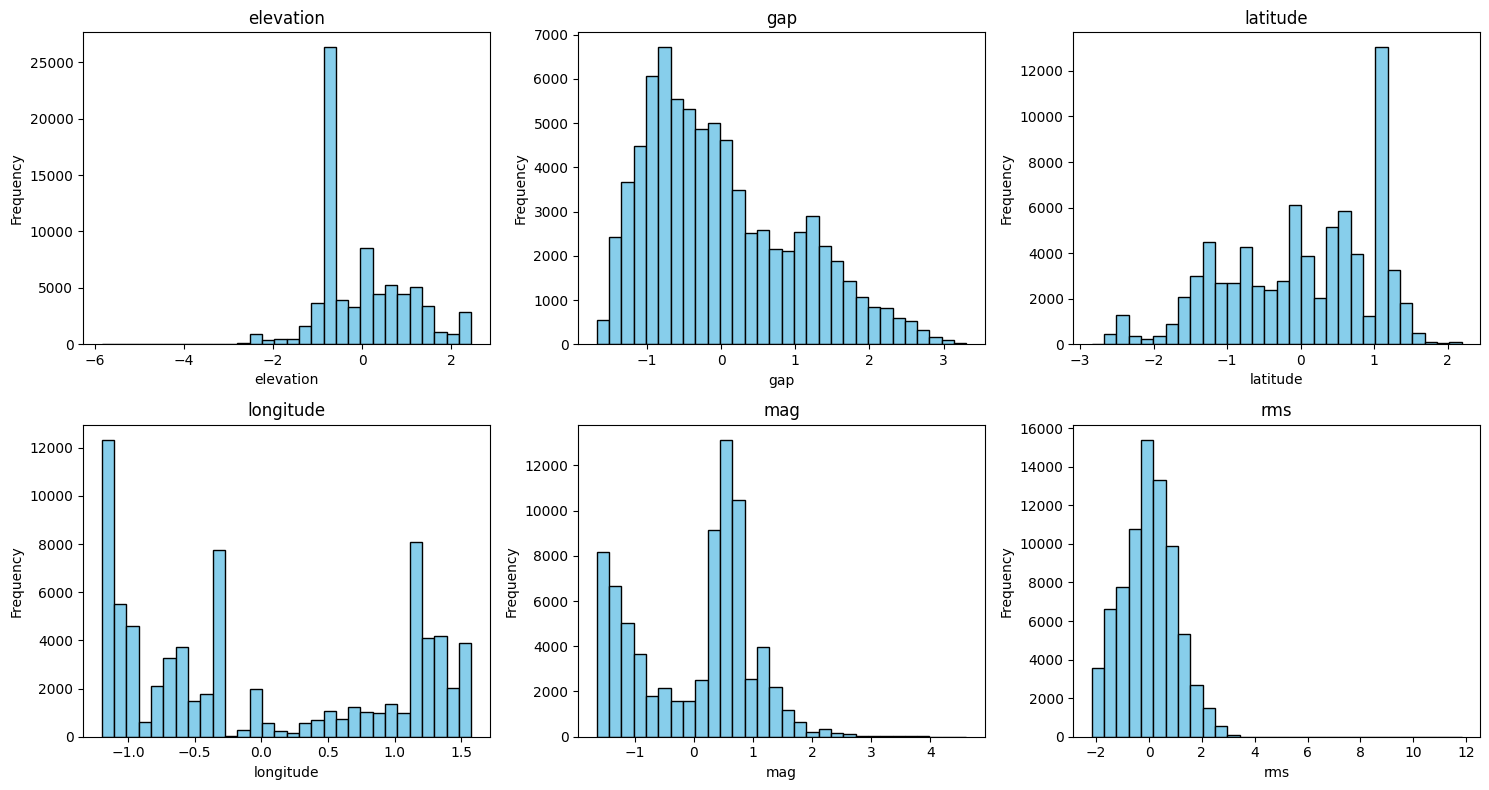

In [80]:
import matplotlib.pyplot as plt 
import numpy as np

# Select only numeric columns, excluding object/categorical columns
num_cols = train_x.select_dtypes(exclude='object').columns
n_cols = 3  # columns in the grid, adjust as needed
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    axes[idx].hist(train_x[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Remove any unused axes if num_cols doesn't fill grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Training

In [2]:
def select_prediction_data(data):
    import pandas as pd
    new_cp_df = data.copy()
    
    rem_vals = data[(data['gap'].isna()) & (data['dmin'].isna())]
    drop_rows = rem_vals.index
    new_cp_df.drop(drop_rows, inplace=True)
    new_cp_df.reset_index(drop=True, inplace=True)
    return new_cp_df, rem_vals

def get_transform(data):
    return DataPreprocessor(data).data_transform(transform=True, log_t=True, square=False)

def get_enc(data):
    cp_df2 = data.copy()
    cp_df3 = DataFile()._encoding(cp_df2)
    return cp_df3

def train_pred_set(data):
    train_data = data[data['dmin_km'].notna()]
    pred_data = data[data['dmin_km'].isna()]
    return train_data, pred_data

z_scorer = None
def _z_score_fit(data,transform=False):
    z_scorer = ZScoreStandard(data)

    fitted = z_scorer.fit_standard_Z()

    if transform:
        return z_scorer.transform_standard_Z(data)
    else:
        return fitted

In [3]:
t_df, p_df = select_prediction_data(x_t)
print(f" Data shapes: {t_df.shape}, {p_df.shape}")
print(f"\n Data columns: {t_df.columns}, {p_df.columns}")
print(f"\n Data na values: {t_df.isna().sum()}, {p_df.isna().sum()}")
print(f"\n Data describe: {t_df.describe()}, {p_df.describe()}")


 Data shapes: (113138, 8), (254, 8)

 Data columns: Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
       'rms'],
      dtype='object'), Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
       'rms'],
      dtype='object')

 Data na values: dmin         2445
elevation       0
gap             0
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64, dmin         254
elevation      0
gap          254
latitude       0
longitude      0
mag            0
magType        0
rms            0
dtype: int64

 Data describe:                 dmin      elevation            gap       latitude  \
count  110693.000000  113138.000000  113138.000000  113138.000000   
mean        2.431387      62.289460     128.331855      20.665266   
std         3.969295     111.422408      69.719825      30.954446   
min         0.000000      -3.740000       8.000000     -84.493200   
25%         0.456000      10.0

In [5]:
x_t.shape

(113392, 8)

In [6]:
x_t.isna().sum().to_dict()

{'dmin': 2699,
 'elevation': 0,
 'gap': 254,
 'latitude': 0,
 'longitude': 0,
 'mag': 0,
 'magType': 0,
 'rms': 0}

In [7]:
def get_skew(data):
    for i in data.select_dtypes(exclude='object').columns:
        print(f"{i} --> {data[i].skew()}")

get_skew(x_t)

dmin --> 4.741359657422391
elevation --> 3.321751453939877
gap --> 0.6323492767797373
latitude --> -0.5565485026108005
longitude --> 0.252843661761184
mag --> -0.1415358328598202
rms --> 0.18176222633491418


In [20]:
cp_df3.corr() 

### 'ml' type earthquake has a good correlation with latitude, could be a point to look into
### 'mb' type earthquake has a good correlation with longitude, could be a point to look into

,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_km
elevation,1.000000,-0.136509,-0.285516,-0.015864,0.170006,0.098932,0.247132,-0.185843,-0.093774,-0.016096,-0.031121,-0.030918,-0.028032,-0.019092,0.052399
gap,-0.136509,1.000000,0.211928,-0.212591,-0.378439,-0.186240,-0.244564,0.208895,0.324698,-0.219285,-0.087994,-0.028407,-0.032260,-0.035171,-0.114722
latitude,-0.285516,0.211928,1.000000,-0.194081,-0.540919,-0.136484,-0.472990,0.552489,0.018177,-0.110193,-0.023730,0.035442,0.035060,0.011678,-0.394699
longitude,-0.015864,-0.212591,-0.194081,1.000000,0.553345,0.244518,0.534878,-0.536826,-0.135483,0.101245,0.006985,-0.049025,-0.032888,-0.021599,0.178495
mag,0.170006,-0.378439,-0.540919,0.553345,1.000000,0.463818,0.679054,-0.752504,-0.293154,0.387084,0.073046,0.001271,-0.073480,-0.031096,0.376799
rms,0.098932,-0.186240,-0.136484,0.244518,0.463818,1.000000,0.419986,-0.273973,-0.394763,0.117161,0.070274,-0.092400,-0.013177,-0.050474,0.140000
mb,0.247132,-0.244564,-0.472990,0.534878,0.679054,0.419986,1.000000,-0.707803,-0.330264,-0.243864,-0.151519,-0.070421,-0.061661,-0.045160,0.345562
ml,-0.185843,0.208895,0.552489,-0.536826,-0.752504,-0.273973,-0.707803,1.000000,-0.197897,-0.146126,-0.090792,-0.042197,-0.036948,-0.027060,-0.304241
md,-0.093774,0.324698,0.018177,-0.135483,-0.293154,-0.394763,-0.330264,-0.197897,1.000000,-0.068183,-0.042364,-0.019689,-0.017240,-0.012626,-0.145049
mww,-0.016096,-0.219285,-0.110193,0.101245,0.387084,0.117161,-0.243864,-0.146126,-0.068183,1.000000,-0.031281,-0.014538,-0.012730,-0.009323,0.080896


In [3]:
class DataSetsPrep:
    def __init__(self, data):
        self.data = data

    def split_data(self):
        self.train_df, self.pred_df = select_prediction_data(self.data)
        return self.train_df, self.pred_df

    def train_prep(self, data):
        cp_df3 = get_transform(data)
        # print(cp_df3.columns)
        # return 
        train_x, train_y = Data_Sets.split_dataset_xy(df=cp_df3, target_col='dmin_km')
        train_x = _z_score_fit(train_x, transform=False)
        # get_skew(train_x)

        train_x = get_enc(train_x)
        train_x = train_x.drop('others', axis=1)
        return train_x, train_y

    def pred_prep(self, data):
        cp_df3 = get_transform(data)
        # print(cp_df3.columns)
        return cp_df3
        # pred_x, _ = Data_Sets.split_dataset_xy(df=cp_df3, target_col='dmin_km', validation_flag=True)
        pred_x = cp_df3.drop(columns=['dmin_km'])
        pred_x = _z_score_fit(pred_x, transform=False)
        # get_skew(train_x)

        pred_x = get_enc(pred_x)
        pred_x = pred_x.drop('others', axis=1)
        return pred_x, 


In [21]:
d = DataSetsPrep(x_t)
train_df, pred_df = d.split_data()
# DataSetsPrep(train_df).train_prep(train_df)
train_x, train_y = d.train_prep(train_df)
# pred_x, pred_y = d.pred_prep(pred_df)
d.pred_prep(pred_df)

# train_df.shape, pred_df.shape

Log Transformation Used!
Log Transformation Used!


c:\Projs\COde\Earthquake\eq_prediction\src\preprocessing\data_preprocessing.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.dataframe['dmin_km'] = self.dataframe['dmin'].apply(lambda x: x * 111.19)


,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,
611,5.437644,NaN,52.5028,-173.3523,3.1,ml,0.42,NaN
684,0.000000,NaN,63.9316,-149.0216,2.5,ml,0.61,NaN
775,2.667228,NaN,64.4676,-147.9417,3.1,ml,0.93,NaN
1533,4.074142,NaN,65.2342,-135.2062,2.8,ml,0.61,NaN
2087,4.888844,NaN,59.9498,-153.4192,3.2,ml,0.73,NaN
...,...,...,...,...,...,...,...,...
104102,3.563883,NaN,61.6829,-149.5429,2.5,ml,0.58,NaN
105397,0.000000,NaN,-8.5510,122.7800,3.0,ml,0.09,NaN
105613,4.677491,NaN,60.0119,-153.0373,2.5,ml,0.37,NaN


In [22]:
pred_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,,
611,NaN,229.9,NaN,52.5028,-173.3523,3.1,ml,0.42,NaN
684,NaN,0.0,NaN,63.9316,-149.0216,2.5,ml,0.61,NaN
775,NaN,14.4,NaN,64.4676,-147.9417,3.1,ml,0.93,NaN
1533,NaN,58.8,NaN,65.2342,-135.2062,2.8,ml,0.61,NaN
2087,NaN,132.8,NaN,59.9498,-153.4192,3.2,ml,0.73,NaN
...,...,...,...,...,...,...,...,...,...
104102,NaN,35.3,NaN,61.6829,-149.5429,2.5,ml,0.58,NaN
105397,NaN,0.0,NaN,-8.5510,122.7800,3.0,ml,0.09,NaN
105613,NaN,107.5,NaN,60.0119,-153.0373,2.5,ml,0.37,NaN


In [15]:
train_x.skew()

elevation     0.221189
gap           0.685331
latitude     -0.472562
longitude     0.320926
mag          -0.115829
rms           0.205443
mb           -0.115300
ml            0.856872
md            2.838586
mww           4.318125
mwr           6.630860
mw           15.889760
dtype: float64

In [18]:
train_df.shape, pred_df.shape

((113138, 9), (254, 8))

In [19]:
train_df.columns, pred_df.columns

(Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
        'rms', 'dmin_km'],
       dtype='object'),
 Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
        'rms'],
       dtype='object'))

In [100]:
# Modeling
from src.model.lr_scratch import LinearR

model = LinearR(train_x, train_y, 20000)
model.fit(train_x, train_y)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
(77485, 14) (77485,)
Training Started
 
Iteration #0 with cost 12.190138057441976
 
Iteration #100 with cost 9.210118630049436
 
Iteration #200 with cost 7.02417849551515
 
Iteration #300 with cost 5.410362654344961
 
Iteration #400 with cost 4.212651248580956
 
Iteration #500 with cost 3.319943635181965
 
Iteration #600 with cost 2.6522364990399567
 
Iteration #700 with cost 2.1513729903205525
 
Iteration #800 with cost 1.774744624066093
 
Iteration #900 with cost 1.4909338569497832
 
Iteration #1000 with cost 1.276654663269218
 
Iteration #1100 with cost 1.11457622686367
 
Iteration #1200 with cost 0.9917572536465259
 
Iteration #1300 with cost 0.8985087717150215
 
Iteration #1400 with cost 0.8275615820454996
 
Iteration #1500 with cost 0.7734527860504634
 
Iteration #1600 with cost 0.7320713739825117
 
Iteration #1700 with cost 0.7003202243208122
 
Iteration #1800 with cost 0.6758638573793113
 
Iteration #1900

In [85]:
train_y

0        5.566506
1        5.297915
2        5.221666
3        1.460100
4        3.797447
           ...   
79921    5.159126
79922    5.960282
79923    3.617616
79924    5.900303
79925    3.764491
Name: dmin_km, Length: 77485, dtype: float64

In [107]:
pred_x, pred_y = Data_Sets.split_dataset_xy(df=pred_df, target_col='dmin_km')
# pred_x
pred_x = _z_score_fit(pred_x, transform=True)
# # get_skew(train_x)

pred_x = get_enc(pred_x)
pred_x
# pred_x = pred_x.drop('others', axis=1)
# model.predict(pred_x, pred_y)

,elevation,gap,latitude,longitude,mag,rms,md,ml,others
5,-1.432105,-2.483017,-7.068343,2.182725,-3.077949,-7.538944,0,1,0
42,-2.316297,-2.465641,-7.251421,2.223334,-9.564218,-7.538944,1,0,0
51,-1.763454,-2.456857,-7.255117,2.223367,-9.386512,-5.464804,1,0,0
60,-1.392616,-2.481489,-7.074605,2.182693,-1.034330,-7.538944,0,1,0
62,-1.506041,-2.448073,-7.131809,2.223162,-9.741924,0.757616,1,0,0
...,...,...,...,...,...,...,...,...,...
25107,-1.442953,-2.482635,-7.077194,2.182692,-7.254040,-9.613084,0,1,0
25110,-2.129765,-2.443491,-7.129102,2.182816,-11.963249,-5.464804,1,0,0
25114,-1.445786,-2.471751,-7.070791,2.182732,-10.808160,-7.538944,0,1,0
25121,-1.333861,-2.481871,-7.073686,2.182692,-12.052102,-7.538944,0,1,0


In [106]:
pred_x

,elevation,gap,latitude,longitude,mag,rms,md,ml,others
5,-1.432105,-2.483017,-7.068343,2.182725,-3.077949,-7.538944,0,1,0
42,-2.316297,-2.465641,-7.251421,2.223334,-9.564218,-7.538944,1,0,0
51,-1.763454,-2.456857,-7.255117,2.223367,-9.386512,-5.464804,1,0,0
60,-1.392616,-2.481489,-7.074605,2.182693,-1.034330,-7.538944,0,1,0
62,-1.506041,-2.448073,-7.131809,2.223162,-9.741924,0.757616,1,0,0
...,...,...,...,...,...,...,...,...,...
25107,-1.442953,-2.482635,-7.077194,2.182692,-7.254040,-9.613084,0,1,0
25110,-2.129765,-2.443491,-7.129102,2.182816,-11.963249,-5.464804,1,0,0
25114,-1.445786,-2.471751,-7.070791,2.182732,-10.808160,-7.538944,0,1,0
25121,-1.333861,-2.481871,-7.073686,2.182692,-12.052102,-7.538944,0,1,0


----

### Imputing Last of the missing values via KNN and Regression

In [5]:
print(f"{x_t.head(10)} \n\n {x_t.shape}")

        dmin  elevation    gap   latitude   longitude   mag magType   rms
idx                                                                      
0    2.35200     10.000  255.0  52.808600 -157.576700  3.40      ml  0.56
1    1.79800     44.780  175.0 -31.059400 -178.100900  4.40      mb  0.58
2    1.66600    190.770   89.0 -24.109100  -66.867300  4.30      mb  0.87
3    0.03873      2.750   41.0  34.165333  -80.727000  3.60      mw  0.34
4    0.40100    199.832  309.0  52.605300 -173.729600  2.90      ml  0.46
5        NaN     32.720   89.0  19.248000 -155.399333  3.51      ml  0.12
6    4.38200     10.000  164.0 -18.154500 -173.005600  4.40      mb  0.37
7    0.04060     15.000  167.0  17.966500  -66.839500  3.22      md  0.22
8    3.90100    605.630  122.0 -14.883300  175.271900  4.40      mb  0.76
9    0.43100     62.450  122.0 -28.835600  -71.151000  4.30      mb  0.71 

 (113392, 8)


In [4]:
x_t2 = get_enc(x_t)
x_t2['dmin_missing'] = x_t2['dmin'].isna().astype(int)
x_t2['gap_missing'] = x_t2['gap'].isna().astype(int)
x_t2

,dmin,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_missing,gap_missing
idx,,,,,,,,,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,0.56,0,1,0,0,0,0,0,0,0,0
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,0.58,1,0,0,0,0,0,0,0,0,0
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,0.87,1,0,0,0,0,0,0,0,0,0
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,0.34,0,0,0,0,0,1,0,0,0,0
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,0.46,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,0.48,0,1,0,0,0,0,0,0,0,0
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,0.27,0,1,0,0,0,0,0,0,0,0
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,1.30,0,1,0,0,0,0,0,0,0,0


In [5]:
# max(x_t2['latitude']), min(x_t2['latitude'])
# max(x_t2['longitude']), min(x_t2['longitude'])
max(x_t2['mag']), min(x_t2['mag'])

(8.8, 2.5)

In [5]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer


class KNNImpute:
    def __init__(self, data, num_neighbors=5, cols=None ):
        self.k = num_neighbors
        self.cols = ['latitude', 'longitude', 'dmin', 'gap', 'rms'] if cols is None else cols
        self.df = data
        self.std_cache = None
        self.GEO_WEIGHT   = 1.0
        self.OTHER_WEIGHT = 0.3
        self._impt = None


    def calc_std(self, df_imp):
        lat_std  = df_imp['latitude'].std()
        lon_std  = df_imp['longitude'].std()
        rms_std  = df_imp['rms'].std()
        gap_std  = df_imp['gap'].std()
        dmin_std = df_imp['dmin'].std()
        
        return {
            'lat_std': lat_std,
            'lon_std': lon_std,
            'rms_std': rms_std,
            'gap_std': gap_std,
            'dmin_std': dmin_std
        }

    def ensure_std(self, df_imp):
      """
      Compute std values once and reuse across methods.
      """
      if self.std_cache is None:
          self.std_cache = self.calc_std(df_imp)
      return self.std_cache

    def knn_impute_seismic(self, df):
        """
        KNN imputation for dmin and gap using geographically-weighted distance.
        """
        
        df_imp = df[self.cols].copy()

        # ── Step 1: Compute scaling factors FROM TRAINING DATA ONLY ──────────────
        # Reuse cached std values
        stds = self.ensure_std(df_imp)
        lat_std = stds['lat_std']
        lon_std = stds['lon_std']
        rms_std = stds['rms_std']
        gap_std = stds['gap_std']
        dmin_std = stds['dmin_std']


        # ── Step 2: Scale with deliberate weights ─────────────────────────────────
        # Geographic features get weight 1.0  → primary driver of neighbor selection
        # Other features get weight 0.3       → present but subordinate
        # Adjust these weights based on domain knowledge


        df_scaled = pd.DataFrame()
        df_scaled['latitude']  = (df_imp['latitude']  / lat_std)  * self.GEO_WEIGHT
        df_scaled['longitude'] = (df_imp['longitude'] / lon_std)  * self.GEO_WEIGHT
        df_scaled['rms']       = (df_imp['rms']       / rms_std)  * self.OTHER_WEIGHT
        df_scaled['gap']       = (df_imp['gap']       / gap_std)  * self.OTHER_WEIGHT
        df_scaled['dmin']      = (df_imp['dmin']       / dmin_std) *self.OTHER_WEIGHT

        return df_scaled


    def _knn_fitputer(self, df, weights='distance'):

        k_imp_data = self.knn_impute_seismic(df)
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        self._impt = imputer

        imputed_scaled = imputer.fit_transform(k_imp_data)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=k_imp_data.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        k_imp_data.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        k_imp_data.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return k_imp_data


    def _knn_transputer(self, df, weights='distance'):

        k_imp_data = self.knn_impute_seismic(df)

        self.std_cache = self.ensure_std(self.df[self.cols].copy())  
        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = self._impt
        imputed_scaled = imputer.transform(k_imp_data)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=k_imp_data.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        k_imp_data.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        k_imp_data.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return k_imp_data

    def _knn_puter_ft(self, df, weights='distance'):
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        imputed_scaled = imputer.fit_transform(df)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=self.df.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return df

    def _knn_puter_f_t(self, train_df, test_df=None, weights='distance', transforms=True):

        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        # print(self.std_cache, type(self.std_cache))
        self.ensure_std(self.df[self.cols].copy()) 
       
        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']
        # print(self.std_cache)
        # return

        training_imputed_scaled = imputer.fit_transform(self.df)
        
        if transforms and test_df:
            validation_imputed_scaled = imputer.transform(test_df
            )
            df_imputed_scaled = pd.DataFrame(validation_imputed_scaled, columns=self.cols, index=self.df.index)
            
            # ── Step 4: Unscale back to original units ────────────────────────────────
            test_df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
            test_df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

            return test_df

        else:
            df_imputed_scaled = pd.DataFrame(training_imputed_scaled, columns=self.cols, index=self.df.index)

            # ── Step 4: Unscale back to original units ────────────────────────────────
            train_df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
            train_df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

            return train_df



In [10]:
x_t2.isna().sum()

dmin            2699
elevation          0
gap              254
latitude           0
longitude          0
mag                0
rms                0
mb                 0
ml                 0
md                 0
mww                0
mwr                0
mw                 0
mb_lg              0
others             0
dmin_missing       0
gap_missing        0
dtype: int64

In [6]:
## This method of splitting is quite biased as one missing of 'gap' is majorly on the end of the dataframe,
## While majority of the missingess in 'dmin' is from the training set.

# d = DataSetsPrep(x_t2)
# train_df, pred_df = d.split_data() 
# print(train_df.shape, pred_df.shape, "\n")
# print(train_df.isna().sum().to_dict(), "\n\n",pred_df.isna().sum().to_dict())


from sklearn.model_selection import train_test_split

df = x_t2.copy()
df["gap_missing"] = df["gap"].isna().astype(int)

train_df, pred_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gap_missing"]  # keeps missing-rate similar in both sets
)

print(train_df.shape, pred_df.shape, "\n")
print(train_df.isna().sum().to_dict(), "\n\n",pred_df.isna().sum().to_dict())

(90713, 17) (22679, 17) 

{'dmin': 2158, 'elevation': 0, 'gap': 203, 'latitude': 0, 'longitude': 0, 'mag': 0, 'rms': 0, 'mb': 0, 'ml': 0, 'md': 0, 'mww': 0, 'mwr': 0, 'mw': 0, 'mb_lg': 0, 'others': 0, 'dmin_missing': 0, 'gap_missing': 0} 

 {'dmin': 541, 'elevation': 0, 'gap': 51, 'latitude': 0, 'longitude': 0, 'mag': 0, 'rms': 0, 'mb': 0, 'ml': 0, 'md': 0, 'mww': 0, 'mwr': 0, 'mw': 0, 'mb_lg': 0, 'others': 0, 'dmin_missing': 0, 'gap_missing': 0}


In [7]:
## Custom function Imputer

# Fit on train only
knn_imp = KNNImpute(data=train_df, num_neighbors=5, cols=['latitude', 'longitude', 'dmin', 'gap', 'rms'])
# knn_imp._knn_puter_f_t(train_df=train_df)
X_train_imp = knn_imp._knn_fitputer(train_df)

# # Transform validation/test with same fitted stats + imputer
X_valid_imp = knn_imp._knn_transputer(pred_df)

---
### BKP funcs + Viz

In [ ]:
## BKP

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer


class KNNImpute:
    """
    KNN imputation with weighted feature scaling for seismic features.
    - Fit on training data only
    - Transform train/valid/test using fitted stats + fitted imputer
    """

    def __init__(self, num_neighbors=5, cols=None, geo_weight=1.0, other_weight=0.3):
        self.k = num_neighbors
        self.cols = ['latitude', 'longitude', 'dmin', 'gap', 'rms'] if cols is None else cols
        self.GEO_WEIGHT = geo_weight
        self.OTHER_WEIGHT = other_weight

        self.means_ = None
        self.stds_ = None
        self.imputer_ = None
        self._is_fitted = False

    def _compute_stats(self, df: pd.DataFrame):
        means = df[self.cols].mean(numeric_only=True)
        stds = df[self.cols].std(numeric_only=True)

        # Prevent divide-by-zero / NaN std issues
        stds = stds.replace(0, np.nan).fillna(1.0)

        self.means_ = means
        self.stds_ = stds

    def _scale(self, df: pd.DataFrame) -> pd.DataFrame:
        if self.means_ is None or self.stds_ is None:
            raise RuntimeError("Scaler stats are not fitted. Call fit() first.")

        x = df[self.cols].copy()

        # Standardize: (x - mean) / std
        x_scaled = (x - self.means_) / self.stds_

        # Apply domain weights
        if 'latitude' in x_scaled.columns:
            x_scaled['latitude'] *= self.GEO_WEIGHT
        if 'longitude' in x_scaled.columns:
            x_scaled['longitude'] *= self.GEO_WEIGHT

        for col in ['rms', 'gap', 'dmin']:
            if col in x_scaled.columns:
                x_scaled[col] *= self.OTHER_WEIGHT

        return x_scaled

    def _unscale_targets(self, scaled_imputed: pd.DataFrame, original_df: pd.DataFrame) -> pd.DataFrame:
        """
        Only write back imputed dmin/gap in original units.
        Non-missing original values are preserved.
        """
        out = original_df.copy()

        for target in ['dmin', 'gap']:
            if target not in self.cols or target not in out.columns:
                continue

            # reverse weight then reverse standardization
            recovered = (
                (scaled_imputed[target] / self.OTHER_WEIGHT) * self.stds_[target]
                + self.means_[target]
            )

            missing_mask = out[target].isna()
            out.loc[missing_mask, target] = recovered.loc[missing_mask]

        return out

    def fit(self, train_df: pd.DataFrame, weights='distance'):
        train_view = train_df[self.cols].copy()

        self._compute_stats(train_view)

        train_scaled = self._scale(train_df)
        self.imputer_ = KNNImputer(n_neighbors=self.k, weights=weights)
        self.imputer_.fit(train_scaled)

        self._is_fitted = True
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self._is_fitted:
            raise RuntimeError("KNNImpute is not fitted. Call fit() before transform().")

        scaled = self._scale(df)
        imputed_scaled_arr = self.imputer_.transform(scaled)
        imputed_scaled = pd.DataFrame(imputed_scaled_arr, columns=self.cols, index=df.index)

        # Write back only dmin/gap missing values in original units
        out = self._unscale_targets(imputed_scaled, df)
        return out

    def fit_transform(self, train_df: pd.DataFrame, weights='distance') -> pd.DataFrame:
        self.fit(train_df, weights=weights)
        return self.transform(train_df)

In [15]:
rem_vals = x_t2[(x_t2['gap'].isna()) & (x_t2['dmin'].isna())]
drop_rows = rem_vals.index
drop_rows

Index([   611,    684,    775,   1533,   2087,   3139,   3330,   3958,   4055,
         4296,
       ...
       100532, 100585, 100797, 103647, 104051, 104102, 105397, 105613, 105617,
       106513],
      dtype='int64', name='idx', length=254)

In [ ]:
## Claude's function for Practical ordering imputation
def impute_in_order(df_train, df_test, k=5):

    cols = ['latitude', 'longitude', 'rms', 'gap', 'dmin']

    # Fit ONLY on training data
    scaler_params = {col: df_train[col].std() for col in cols}

    def scale(df):
        scaled = df[cols].copy()
        for col in ['latitude', 'longitude']:
            scaled[col] = (df[col] / scaler_params[col]) * 1.0   # geo weight
        for col in ['rms', 'gap', 'dmin']:
            scaled[col] = (df[col] / scaler_params[col]) * 0.3   # other weight
        return scaled

    imputer = KNNImputer(n_neighbors=k, weights='distance')
    
    # Fit and transform train
    train_scaled  = scale(df_train)
    train_imputed = imputer.fit_transform(train_scaled)   # fit here ✅

    # Transform test using the SAME fitted imputer
    test_scaled   = scale(df_test)
    test_imputed  = imputer.transform(test_scaled)        # NOT fit_transform ✅

    # Unscale and write back only the imputed columns
    for df_orig, arr in [(df_train, train_imputed), (df_test, test_imputed)]:
        df_orig['gap']  = arr[:, cols.index('gap')]  * (scaler_params['gap']  / 0.3)
        df_orig['dmin'] = arr[:, cols.index('dmin')] * (scaler_params['dmin'] / 0.3)

    return df_train, df_test

In [34]:
t_df, p_df = impute_in_order(train_df, pred_df)

In [ ]:
t_df.shape, p_df.shape

(90713, 17)

In [38]:
t_df.describe()

,dmin,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_missing,gap_missing
count,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000
mean,2.380907,62.035819,128.423785,20.800986,-21.072571,3.882031,0.594396,0.541102,0.299483,0.083913,0.047667,0.018531,0.004200,0.003318,0.001786,0.023789,0.002238
std,3.953698,110.890240,69.751304,30.931713,130.757955,0.852308,0.280061,0.498310,0.458034,0.277259,0.213061,0.134862,0.064672,0.057508,0.042222,0.152393,0.047253
min,0.000000,-3.740000,8.000000,-84.493200,-179.999700,2.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.427000,10.000000,73.000000,-4.420800,-152.336000,3.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.184000,17.100000,117.000000,24.146000,-66.956833,4.200000,0.600000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.739000,60.250000,177.000000,51.175500,126.675700,4.500000,0.780000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,62.558000,681.238000,358.180000,87.081500,179.999400,8.800000,3.730000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
dcols = [x for x, y in X_train_imp.skew().items()]

skew_chk_df = pd.DataFrame({
    'Claude': t_df[dcols].skew(),
    'Cursor_Code': X_train_imp[dcols].skew()
})



import matplotlib.pyplot as plt

# Plot histogram for 'Claude'
def plot_histograms_of_dcols(df, dcols, bins=30, figsize=(16, 2.5)):
    """
    Plots histograms of all columns in `dcols` from the given dataframe `df`.
    Each column gets its own subplot.
    """
    import math
    import matplotlib.pyplot as plt

    n = len(dcols)
    if n == 0:
        print("No columns to plot.")
        return

    # Plot histograms in a single row (wider plots if more columns), or wrap over rows if too many
    ncols = min(n, 4)
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=(figsize[0] * ncols, figsize[1] * nrows))
    for i, col in enumerate(dcols):
        plt.subplot(nrows, ncols, i + 1)
        plt.hist(df[col].dropna(), bins=bins, color='skyblue', edgecolor='black')
        plt.title(f"Histogram of '{col}'")
        plt.xlabel("Value")
        plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

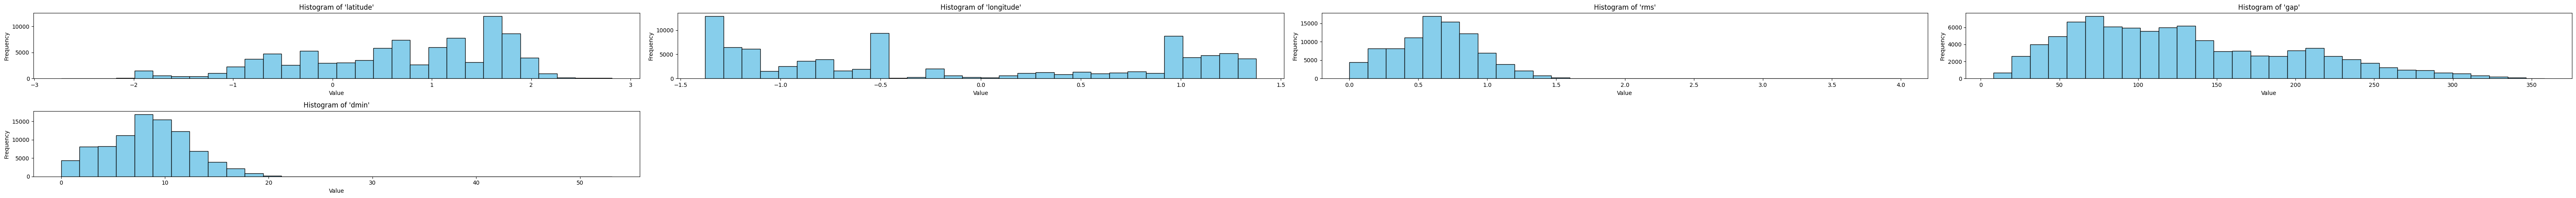

In [53]:
plot_histograms_of_dcols(df=X_train_imp, dcols=dcols)

---
### Data Assimiation and training

In [8]:
X_train_imp

,latitude,longitude,rms,gap,dmin
idx,,,,,
39602,0.176796,0.742730,0.931941,35.0,12.384759
48335,1.004083,-0.064124,0.717702,22.0,9.537688
75265,1.687087,-1.344419,0.299935,170.0,3.985900
7068,-1.868219,-0.192869,0.642718,83.0,8.541213
65156,1.177201,-0.709395,0.171391,59.0,2.277657
...,...,...,...,...,...
14465,0.997242,-0.890114,1.317572,201.0,17.509487
57137,1.667767,1.373276,0.342783,127.0,4.555314
83212,-1.488731,-0.108317,0.974789,71.0,12.954174


In [8]:
# Create a new dataframe with only the index and 'gap' columns from both train_df_filled and pred_df_filled
gap_df = pd.concat(
    [
        X_train_imp[['gap']],
        X_valid_imp[['gap']]
    ],
    axis=0
)
gap_df

,gap
idx,
39602,35.0
48335,22.0
75265,170.0
7068,83.0
65156,59.0
...,...
5643,104.0
82716,111.0
105510,302.0


In [10]:
x_t.shape

(113392, 8)

In [9]:
# Make copies of train_df and pred_df
df_filled = x_t.copy()
print(df_filled.isna().sum())

# Fill missing 'gap' values in train_df from X_train_imp
df_filled['gap'] = df_filled['gap'].fillna(gap_df['gap'])
print(df_filled.isna().sum())

dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64
dmin         2699
elevation       0
gap             0
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64


In [12]:
print(df_filled.select_dtypes(exclude=['object']).skew())

dmin         4.741360
elevation    3.321751
gap          0.631238
latitude    -0.556549
longitude    0.252844
mag         -0.141536
rms          0.181762
dtype: float64


In [10]:
# Split df_filled into training set (where 'dmin' is not null) and prediction set (where 'dmin' is null)
df_filled_train = df_filled[df_filled['dmin'].notnull()]
df_filled_pred = df_filled[df_filled['dmin'].isnull()]
print(df_filled_train.shape, df_filled_pred.shape)
print("\n\n", df_filled_train.isna().sum(), df_filled_pred.isna().sum())

(110693, 8) (2699, 8)


 dmin         0
elevation    0
gap          0
latitude     0
longitude    0
mag          0
magType      0
rms          0
dtype: int64 dmin         2699
elevation       0
gap             0
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64


In [11]:
## BKP

# Make copies of train_df and pred_df
train_df_filled = train_df.copy()
pred_df_filled = pred_df.copy()

# Fill missing 'gap' values in train_df from X_train_imp
train_df_filled['gap'] = train_df_filled['gap'].fillna(X_train_imp['gap'])

# Fill missing 'gap' values in pred_df from X_valid_imp
pred_df_filled['gap'] = pred_df_filled['gap'].fillna(X_valid_imp['gap'])

In [12]:
del train_df_filled
del pred_df_filled

In [17]:
train_df_filled.isna().sum()

dmin            2158
elevation          0
gap                0
latitude           0
longitude          0
mag                0
rms                0
mb                 0
ml                 0
md                 0
mww                0
mwr                0
mw                 0
mb_lg              0
others             0
dmin_missing       0
gap_missing        0
dtype: int64

In [18]:
train_df_filled.skew()

dmin             4.755007
elevation        3.328805
gap              0.628705
latitude        -0.555552
longitude        0.251872
mag             -0.144093
rms              0.190220
mb              -0.164970
ml               0.875574
md               3.001500
mww              4.246128
mwr              7.140328
mw              15.333097
mb_lg           17.273833
others          23.600360
dmin_missing     6.249907
gap_missing     21.068436
dtype: float64

In [19]:
train_df_filled.describe()

,dmin,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_missing,gap_missing
count,88555.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000,90713.000000
mean,2.433234,62.035819,128.423785,20.800986,-21.072571,3.882031,0.594396,0.541102,0.299483,0.083913,0.047667,0.018531,0.004200,0.003318,0.001786,0.023789,0.002238
std,3.986764,110.890240,69.751304,30.931713,130.757955,0.852308,0.280061,0.498310,0.458034,0.277259,0.213061,0.134862,0.064672,0.057508,0.042222,0.152393,0.047253
min,0.000000,-3.740000,8.000000,-84.493200,-179.999700,2.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.455000,10.000000,73.000000,-4.420800,-152.336000,3.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.237000,17.100000,117.000000,24.146000,-66.956833,4.200000,0.600000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.802000,60.250000,177.000000,51.175500,126.675700,4.500000,0.780000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,62.558000,681.238000,358.180000,87.081500,179.999400,8.800000,3.730000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
train_df_filled.corr()

,dmin,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_missing,gap_missing
dmin,1.000000,0.050885,-0.114012,-0.393622,0.177287,0.375566,0.138666,0.345413,-0.303637,-0.143909,0.077439,-0.055481,-0.036821,-0.025301,-0.019232,NaN,NaN
elevation,0.050885,1.000000,-0.137566,-0.284028,-0.010372,0.169281,0.099103,0.245933,-0.184995,-0.092880,-0.016688,-0.029965,-0.031200,-0.028515,-0.019213,-0.055319,-0.012439
gap,-0.114012,-0.137566,1.000000,0.212220,-0.211293,-0.375874,-0.183517,-0.244067,0.208242,0.322644,-0.218604,-0.085677,-0.028459,-0.030567,-0.035227,0.073315,0.003974
latitude,-0.393622,-0.284028,0.212220,1.000000,-0.198500,-0.542396,-0.135884,-0.474789,0.554401,0.016820,-0.110097,-0.025092,0.035548,0.035022,0.012375,0.012323,0.060825
longitude,0.177287,-0.010372,-0.211293,-0.198500,1.000000,0.554378,0.242681,0.536533,-0.537884,-0.134548,0.101125,0.005747,-0.049054,-0.033217,-0.021889,-0.115647,-0.042057
mag,0.375566,0.169281,-0.375874,-0.542396,0.554378,1.000000,0.462246,0.681092,-0.754068,-0.290021,0.385944,0.071898,0.001848,-0.074601,-0.031998,-0.180393,-0.049804
rms,0.138666,0.099103,-0.183517,-0.135884,0.242681,0.462246,1.000000,0.420104,-0.275050,-0.392245,0.116424,0.070619,-0.093497,-0.013199,-0.050451,-0.213005,0.011877
mb,0.345413,0.245933,-0.244067,-0.474789,0.536533,0.681092,0.420104,1.000000,-0.710000,-0.328646,-0.242938,-0.149208,-0.070522,-0.062654,-0.045930,-0.169222,-0.050489
ml,-0.303637,-0.184995,0.208242,0.554401,-0.537884,-0.754068,-0.275050,-0.710000,1.000000,-0.197890,-0.146282,-0.089844,-0.042464,-0.037727,-0.027656,0.075289,0.068865
md,-0.143909,-0.092880,0.322644,0.016820,-0.134548,-0.290021,-0.392245,-0.328646,-0.197890,1.000000,-0.067711,-0.041587,-0.019656,-0.017463,-0.012801,0.219922,-0.014333


In [13]:
# Combine train_df_filled and pred_df_filled
combined_df = pd.concat([df_filled_train, df_filled_pred], axis=0)
combined_df = combined_df.sort_index()

# Split combined_df into training (no missing dmin) and prediction (missing dmin)
combined_train_df = combined_df[combined_df['dmin'].notnull()]
combined_pred_df = combined_df[combined_df['dmin'].isnull()]
combined_pred_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
5,NaN,32.72,89.000000,19.248000,-155.399333,3.51,ml,0.12
42,NaN,6.88,180.000000,17.951833,-66.927333,2.78,md,0.12
51,NaN,18.24,226.000000,17.925667,-66.855333,2.80,md,0.14
60,NaN,35.08,97.000000,19.203667,-155.469167,3.74,ml,0.12
62,NaN,28.72,272.000000,18.798667,-67.303167,2.76,md,0.20
...,...,...,...,...,...,...,...,...
105617,NaN,57.40,114.755005,59.135600,-151.570800,3.90,ml,0.89
106513,NaN,25.20,157.302482,70.871400,-137.153800,2.60,ml,0.71
108737,NaN,1.42,23.000000,38.787833,-122.746167,2.65,md,0.07


In [21]:
combined_train_df.shape, combined_pred_df.shape

((110693, 8), (2699, 8))

In [22]:
del train_df_filled2_X
del pred_df_filled2_X

In [ ]:

train_df_filled2_X, train_df_filled2_s_y = Data_Sets.split_dataset_xy(combined_train_df, target_col='dmin')
pred_df_filled2_X, pred_df_filled2_s_y = Data_Sets.split_dataset_xy(combined_pred_df, target_col='dmin')


# # Scaling/Stamdaradizing
# train_df_filled2_s = DataPreprocessor(train_df_filled2_X).imput_data_transform(log_t=True, dmin_convert=False)
# pred_df_filled2_s = DataPreprocessor(pred_df_filled2_X).imput_data_transform(log_t=True, dmin_convert=False)  

cols_r = train_df_filled2_X.select_dtypes(exclude=['object'])

train_df_filled2_s = ExperimentalDataPreprocessor(train_df_filled2_X).imput_data_transform(log_t=False, dmin_convert=False, cols=cols_r)
pred_df_filled2_s = ExperimentalDataPreprocessor(pred_df_filled2_X).imput_data_transform(log_t=False, dmin_convert=False, cols=cols_r)

train_df_filled2_s_e = get_enc(train_df_filled2_s)
pred_df_filled2_s_e = get_enc(pred_df_filled2_s)

# # Filter the data
# train_df_filled2 = train_df_filled2_s_e.drop(columns=['others'])
# pred_df_filled2 = pred_df_filled2_s_e.drop(columns=['others'])


# z_scorer = ZScoreStandard(train_df_filled2, cols_r)
# train_df_filled2_X = z_scorer.fit_standard_Z()
# pred_df_filled2_X = z_scorer.transform_standard_Z(pred_df_filled2)
# # # f_tx, f_ty = Data_Sets.split_dataset_xy()

In [24]:
train_df_filled2_X.shape, pred_df_filled2_s.shape

((77485, 7), (1889, 7))

In [31]:
print(train_df_filled2_s_e.columns)
print(pred_df_filled2_s_e.columns)

Index(['elevation', 'gap', 'latitude', 'longitude', 'mag', 'rms', 'mb', 'ml',
       'md', 'mww', 'mwr', 'mw', 'mb_lg', 'others'],
      dtype='object')
Index(['elevation', 'gap', 'latitude', 'longitude', 'mag', 'rms', 'md', 'ml',
       'others'],
      dtype='object')


In [17]:
train_df_filled2.head(5), train_df_filled2.shape

(     elevation        gap   latitude  longitude       mag       rms  mb  ml  \
 idx                                                                           
 0     3.162278  15.968719   7.266953  -157.5767  1.843909  0.748331   0   1   
 1     6.691786  13.228757 -31.059400  -178.1009  2.097618  0.761577   1   0   
 2    13.811951   9.433981 -24.109100   -66.8673  2.073644  0.932738   1   0   
 3     1.658312   6.403124   5.845112   -80.7270  1.897367  0.583095   0   0   
 4    14.136195  17.578396   7.252951  -173.7296  1.702939  0.678233   0   1   
 
      md  mww  mwr  mw  mb_lg  
 idx                           
 0     0    0    0   0      0  
 1     0    0    0   0      0  
 2     0    0    0   0      0  
 3     0    0    0   1      0  
 4     0    0    0   0      0  ,
 (77485, 13))

array([[<Axes: title={'center': 'elevation'}>,
        <Axes: title={'center': 'gap'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'mag'}>, <Axes: title={'center': 'rms'}>,
        <Axes: title={'center': 'mb'}>, <Axes: title={'center': 'ml'}>],
       [<Axes: title={'center': 'md'}>, <Axes: title={'center': 'mww'}>,
        <Axes: title={'center': 'mwr'}>, <Axes: title={'center': 'mw'}>],
       [<Axes: title={'center': 'mb_lg'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

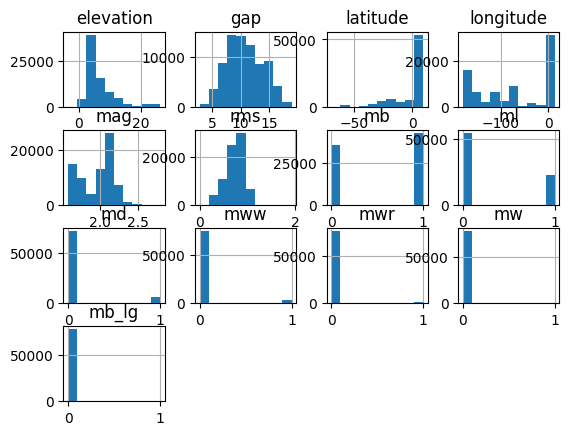

In [22]:
train_df_filled2.hist()

In [21]:
print(train_df_filled2.select_dtypes(exclude=['object']).skew())

elevation     1.844706
gap           0.188117
latitude     -1.970839
longitude    -0.174150
mag          -0.330641
rms          -0.484433
mb           -0.182863
ml            0.885640
md            3.155295
mww           4.240454
mwr           6.525083
mw           15.689534
mb_lg        18.037237
dtype: float64


In [19]:
print(train_df_filled2_s.select_dtypes(exclude=['object']).skew())

elevation    1.844706
gap          0.188117
latitude    -1.970839
longitude   -0.174150
mag         -0.330641
rms         -0.484433
dtype: float64


In [20]:
train_df_filled2_X.skew()

TypeError: could not convert string to float: 'ml'

In [25]:
train_df_filled2_s_y

idx
0        2.35200
1        1.79800
2        1.66600
3        0.03873
4        0.40100
          ...   
80455    1.56500
80456    3.48700
80457    0.33500
80458    3.28400
80459    0.38800
Name: dmin, Length: 77485, dtype: float64

In [26]:
# Modeling
from src.model.lr_scratch import LinearR

model = LinearR(train_df_filled2_X, train_df_filled2_s_y, 100000)
model.fit(train_df_filled2_X, train_df_filled2_s_y)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
(77485, 8) (77485,)
Training Started


TypeError: can't multiply sequence by non-int of type 'float'

In [37]:
train_df_filled2_X

,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg
idx,,,,,,,,,,,,,
0,-0.709488,1.839060,1.091082,-1.026197,-0.583897,-0.067833,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
1,0.405783,0.700814,-1.598845,-1.184503,0.596413,0.007215,0.912741,-0.650844,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
2,1.526136,-0.522801,-1.375925,-0.326544,0.478382,1.095424,0.912741,-0.650844,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
3,-1.551162,-1.205749,0.493130,-0.433446,-0.347835,-0.893371,-1.095601,-0.650844,-0.290236,-0.223996,-0.149818,15.752711,-0.055273
4,1.562248,2.607376,1.084561,-1.150787,-1.174053,-0.443078,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80455,0.864146,1.696779,-1.497929,-1.175896,0.714444,-0.518126,0.912741,-0.650844,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
80456,1.511970,-0.778907,-0.780333,1.323415,0.360351,-0.443078,0.912741,-0.650844,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
80457,0.566423,0.174375,-1.496508,-0.358867,0.596413,0.457508,0.912741,-0.650844,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273


In [38]:
from sklearn.linear_model import LinearRegression

# Instantiate the model
lr_model = LinearRegression(fit_intercept=False)

# Fit the model
lr_model.fit(train_df_filled2_X, train_df_filled2_s_y)

# Print out the coefficients
print("Coefficients:", lr_model.coef_)
print("Intercept:", lr_model.intercept_)

Coefficients: [ 0.01013172  0.47171528 -0.12273429  0.05520733  0.57417317  0.19753648
  1.29561176  0.77987899  0.24469143  0.47930937  0.23026349  0.02180411
  0.14033473]
Intercept: 0.0


In [34]:
model.theta

array([ 4.7098285 ,  0.01241742,  0.45714943, -0.17032993,  0.09484543,
        0.50148959,  0.2391183 ,  0.63205855,  0.19060914, -0.09403448,
        0.20733893,  0.03554274, -0.05180107,  0.06429448])

In [40]:
from sklearn.linear_model import SGDRegressor

# Instantiate the SGD regressor
sgd_reg = SGDRegressor(fit_intercept=False)

# Fit the regressor to the training data
sgd_reg.fit(train_df_filled2_X, train_df_filled2_s_y)

# Print out the intercept
print("SGD Intercept:", sgd_reg.coef_)

SGD Intercept: [ 0.03088691  0.4640776  -0.04511291  0.0572494   0.56621329  0.19510899
  1.25008623  0.63185736  0.23552012  0.39136534  0.17796921 -0.02380017
  0.19036406]


In [49]:
pred_df_filled2_X

,elevation,gap,latitude,longitude,mag,rms,mb,ml,md,mww,mwr,mw,mb_lg
idx,,,,,,,,,,,,,
5,0.166644,-0.522801,0.014682,-1.009403,-0.454063,-1.718908,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
42,-0.970379,0.771954,-0.026891,-0.327007,-1.315690,-1.718908,-1.095601,-0.650844,3.445470,-0.223996,-0.149818,-0.063481,-0.055273
51,-0.272206,1.426446,-0.027730,-0.326452,-1.292084,-1.643859,-1.095601,-0.650844,3.445470,-0.223996,-0.149818,-0.063481,-0.055273
60,0.219553,-0.408977,0.013260,-1.009942,-0.182592,-1.718908,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
62,0.067884,2.080937,0.000270,-0.329906,-1.339296,-1.418713,-1.095601,-0.650844,3.445470,-0.223996,-0.149818,-0.063481,-0.055273
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26836,-1.389675,2.237446,-0.002168,-1.008238,-1.386509,-1.606335,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
26912,0.170808,-0.494345,0.012340,-1.010169,-1.327493,-1.756432,-1.095601,1.536467,-0.290236,-0.223996,-0.149818,-0.063481,-0.055273
26999,0.132752,-0.209783,0.011955,-1.010068,-1.504540,-1.756432,-1.095601,-0.650844,3.445470,-0.223996,-0.149818,-0.063481,-0.055273


In [45]:
c_lr_preds = model.predict(pred_df_filled2_X, pred_df_filled2_s_y)
sk_lr_preds = lr_model.predict(pred_df_filled2_X)
sk_sgd_preds = sgd_reg.predict(pred_df_filled2_X)

In [46]:
sk_lr_preds

array([-1.34594614, -1.99040006, -1.64608005, ..., -2.60064663,
       -0.51946441, -0.75383041])

In [47]:
import pandas as pd

# Combine predictions into a DataFrame
preds_df = pd.DataFrame({
    'custom_lr': c_lr_preds,
    'sklearn_lr': sk_lr_preds,
    'sgd_regressor': sk_sgd_preds
})

preds_df.head()

,custom_lr,sklearn_lr,sgd_regressor
0,3.311571,-1.345946,-1.478856
1,2.760848,-1.990400,-1.862265
2,3.098698,-1.646080,-1.508888
3,3.500594,-1.135701,-1.270655
4,3.427185,-1.320161,-1.178913


In [48]:
train_df_filled2_s_y

idx
0        5.570323
1        5.302905
2        5.227050
3        1.668912
4        3.819627
           ...   
80455    5.164857
80456    5.962858
80457    3.644108
80458    5.903038
80459    3.787405
Name: dmin_km, Length: 77485, dtype: float64

---
## Final compilation

In [1]:
# Final Total function

import os
import sys
sys.path.append(os.path.abspath('..'))
from src.preprocessing.data_preprocessing import EQDataLoader, DataPreprocessor, ZScoreStandard, Data_Sets, ExperimentalDataPreprocessor
from main_new import DataFile


# Get data
dL = EQDataLoader()
x_t = DataFile()._load_final_data()


Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


In [2]:
# Functions
def get_enc(data):
    cp_df2 = data.copy()
    cp_df3 = DataFile()._encoding(cp_df2)
    return cp_df3

def prep_impute_data(data):
    x_t2 = get_enc(data)
    x_t2['dmin_missing'] = x_t2['dmin'].isna().astype(int)
    x_t2['gap_missing'] = x_t2['gap'].isna().astype(int)
    return x_t2

In [5]:
# Imputer

import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer


class KNNImpute:
    def __init__(self, data, num_neighbors=5, cols=None ):
        self.k = num_neighbors
        self.cols = ['latitude', 'longitude', 'dmin', 'gap', 'rms'] if cols is None else cols
        self.df = data
        self.std_cache = None
        self.GEO_WEIGHT   = 1.0
        self.OTHER_WEIGHT = 0.3
        self._impt = None


    def calc_std(self, df_imp):
        lat_std  = df_imp['latitude'].std()
        lon_std  = df_imp['longitude'].std()
        rms_std  = df_imp['rms'].std()
        gap_std  = df_imp['gap'].std()
        dmin_std = df_imp['dmin'].std()
        
        return {
            'lat_std': lat_std,
            'lon_std': lon_std,
            'rms_std': rms_std,
            'gap_std': gap_std,
            'dmin_std': dmin_std
        }

    def ensure_std(self, df_imp):
      """
      Compute std values once and reuse across methods.
      """
      if self.std_cache is None:
          self.std_cache = self.calc_std(df_imp)
      return self.std_cache

    def knn_impute_seismic(self, df):
        """
        KNN imputation for dmin and gap using geographically-weighted distance.
        """
        
        df_imp = df[self.cols].copy()

        # ── Step 1: Compute scaling factors FROM TRAINING DATA ONLY ──────────────
        # Reuse cached std values
        stds = self.ensure_std(df_imp)
        lat_std = stds['lat_std']
        lon_std = stds['lon_std']
        rms_std = stds['rms_std']
        gap_std = stds['gap_std']
        dmin_std = stds['dmin_std']


        # ── Step 2: Scale with deliberate weights ─────────────────────────────────
        # Geographic features get weight 1.0  → primary driver of neighbor selection
        # Other features get weight 0.3       → present but subordinate
        # Adjust these weights based on domain knowledge


        df_scaled = pd.DataFrame()
        df_scaled['latitude']  = (df_imp['latitude']  / lat_std)  * self.GEO_WEIGHT
        df_scaled['longitude'] = (df_imp['longitude'] / lon_std)  * self.GEO_WEIGHT
        df_scaled['rms']       = (df_imp['rms']       / rms_std)  * self.OTHER_WEIGHT
        df_scaled['gap']       = (df_imp['gap']       / gap_std)  * self.OTHER_WEIGHT
        df_scaled['dmin']      = (df_imp['dmin']       / dmin_std) *self.OTHER_WEIGHT

        return df_scaled


    def _knn_fitputer(self, df, weights='distance'):

        k_imp_data = self.knn_impute_seismic(df)
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        self._impt = imputer

        imputed_scaled = imputer.fit_transform(k_imp_data)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=k_imp_data.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        k_imp_data.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        k_imp_data.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return k_imp_data


    def _knn_transputer(self, df, weights='distance'):

        k_imp_data = self.knn_impute_seismic(df)

        self.std_cache = self.ensure_std(self.df[self.cols].copy())  
        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = self._impt
        imputed_scaled = imputer.transform(k_imp_data)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=k_imp_data.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        k_imp_data.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        k_imp_data.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return k_imp_data

    def _knn_puter_ft(self, df, weights='distance'):
    
        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        imputed_scaled = imputer.fit_transform(df)

        df_imputed_scaled = pd.DataFrame(imputed_scaled, columns=self.cols, index=self.df.index)

        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']

        # ── Step 4: Unscale back to original units ────────────────────────────────
        df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
        df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

        return df

    def _knn_puter_f_t(self, train_df, test_df=None, weights='distance', transforms=True):

        # ── Step 3: Run KNN on the scaled space ───────────────────────────────────
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        # print(self.std_cache, type(self.std_cache))
        self.ensure_std(self.df[self.cols].copy()) 
       
        gap_std, dmin_std = self.std_cache['gap_std'], self.std_cache['dmin_std']
        # print(self.std_cache)
        # return

        training_imputed_scaled = imputer.fit_transform(self.df)
        
        if transforms and test_df:
            validation_imputed_scaled = imputer.transform(test_df)
            df_imputed_scaled = pd.DataFrame(validation_imputed_scaled, columns=self.cols, index=self.df.index)
            
            # ── Step 4: Unscale back to original units ────────────────────────────────
            test_df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
            test_df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

            return test_df

        else:
            df_imputed_scaled = pd.DataFrame(training_imputed_scaled, columns=self.cols, index=self.df.index)

            # ── Step 4: Unscale back to original units ────────────────────────────────
            train_df.loc[:, 'dmin'] = df_imputed_scaled['dmin'] * (dmin_std / self.OTHER_WEIGHT)
            train_df.loc[:, 'gap']  = df_imputed_scaled['gap']  * (gap_std  / self.OTHER_WEIGHT)

            return train_df



In [6]:
# Calling functions

# Call data
# Assuming x_t exists in your workspace

# Run x_t through get_enc and prep_impute_Data
x_t_prep = prep_impute_data(x_t)

# Split data for imputer
train_df, pred_df = Data_Sets.stratify_split(x_t_prep)

# CAll imputer 
# Fit on train only
knn_imp = KNNImpute(data=train_df, num_neighbors=5, cols=['latitude', 'longitude', 'dmin', 'gap', 'rms'])
# knn_imp._knn_puter_f_t(train_df=train_df)
X_train_imp = knn_imp._knn_fitputer(train_df)
# # Transform validation/test with same fitted stats + imputer
X_valid_imp = knn_imp._knn_transputer(pred_df)

In [7]:
X_valid_imp['gap'].max(), X_valid_imp['gap'].min()

(353.0, 10.0)

In [8]:
X_train_imp['gap'].max(), X_train_imp['gap'].min()

(358.17999999999995, 7.999999999999999)

In [6]:
## Recombining the data and the imputed values into the original data

# Create a new dataframe with only the index and 'gap' columns from both train_df_filled and pred_df_filled
gap_df = pd.concat(
    [
        X_train_imp[['gap']],
        X_valid_imp[['gap']]
    ],
    axis=0
)


## Patching the missing values back
# Make copies of train_df and pred_df
df_filled = x_t.copy()
df_filled['gap'] = df_filled['gap'].fillna(gap_df['gap'])

# Split df_filled into training set (where 'dmin' is not null) and prediction set (where 'dmin' is null)
df_filled_train = df_filled[df_filled['dmin'].notnull()]
df_filled_pred = df_filled[df_filled['dmin'].isnull()]


##  SPlit the data based on emty values
# Combine train_df_filled and pred_df_filled
combined_df = pd.concat([df_filled_train, df_filled_pred], axis=0)
combined_df = combined_df.sort_index()

# Split combined_df into training (no missing dmin) and prediction (missing dmin)
combined_train_df = combined_df[combined_df['dmin'].notnull()]
combined_pred_df = combined_df[combined_df['dmin'].isnull()]

In [7]:
combined_train_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [8]:
fin_combined_df = pd.concat([combined_train_df, combined_pred_df], axis=0)
# fin_combined_df2 = fin_combined_df.sort_index()
fin_combined_df[(fin_combined_df.shape[0] - 2699):].isna().sum()

dmin         2699
elevation       0
gap             0
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64

In [9]:
cols_r = fin_combined_df.select_dtypes(exclude=['object'])
fin_combined_df2_s_X, fin_combined_df2_s_y = Data_Sets.split_dataset_xy(fin_combined_df, target_col='dmin', set_split=False)

cols_r = fin_combined_df2_s_X.select_dtypes(include=['float64']).columns
fin_combined_df2_s_X = ExperimentalDataPreprocessor(fin_combined_df2_s_X).imput_data_transform(log_t=False, square=False, dmin_convert=False, cols=cols_r)
fin_combined_df2_s_X_e = get_enc(fin_combined_df2_s_X)

split_idx = fin_combined_df2_s_X_e.shape[0] - 2699
# Split fin_combined_df2_s_X_e into training and prediction sets using split_idx
train_df2_X = fin_combined_df2_s_X_e.iloc[:split_idx].copy()
train_df2_y = fin_combined_df2_s_y.iloc[:split_idx].copy()

pred_df2_X = fin_combined_df2_s_X_e.iloc[split_idx:].copy()
pred_df2_y = fin_combined_df2_s_y.iloc[split_idx:].copy()

In [10]:
fin_combined_df2_s_X_e.skew()

elevation     1.323265
gap          -0.088495
latitude     -0.922613
longitude     0.340334
mag          -0.347857
rms          -0.733595
mb           -0.161917
ml            0.876396
md            2.991401
mww           4.236582
mwr           7.042018
mw           15.386352
mb_lg        17.589373
others       23.929287
dtype: float64

In [11]:
train_df2_X.shape, pred_df2_X.shape

((110693, 14), (2699, 14))

In [12]:
print(train_df2_X.info())
print(pred_df2_X.info())

<class 'pandas.core.frame.DataFrame'>
Index: 110693 entries, 0 to 114219
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   elevation  110693 non-null  float64
 1   gap        110693 non-null  float64
 2   latitude   110693 non-null  float64
 3   longitude  110693 non-null  float64
 4   mag        110693 non-null  float64
 5   rms        110693 non-null  float64
 6   mb         110693 non-null  int64  
 7   ml         110693 non-null  int64  
 8   md         110693 non-null  int64  
 9   mww        110693 non-null  int64  
 10  mwr        110693 non-null  int64  
 11  mw         110693 non-null  int64  
 12  mb_lg      110693 non-null  int64  
 13  others     110693 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 12.7 MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 2699 entries, 5 to 113906
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  ----- 

In [13]:
pred_df2_y

idx
5        NaN
42       NaN
51       NaN
60       NaN
62       NaN
          ..
105617   NaN
106513   NaN
108737   NaN
113902   NaN
113906   NaN
Name: dmin, Length: 2699, dtype: float64

In [14]:
z_scorer = ZScoreStandard(train_df2_X, cols_r)
train_df_filled2_X = z_scorer.fit_standard_Z()
pred_df_filled2_X = z_scorer.transform_standard_Z(pred_df2_X)
# # # f_tx, f_ty = Data_Sets.split_dataset_xy()

In [15]:
pred_df_filled2_X.shape == pred_df2_X.shape

True

In [31]:
# Modeling


from src.model.lr_scratch import LinearR
from sklearn.linear_model import LinearRegression, SGDRegressor

class MDLS:
    def __init__(self, train_X, train_y, n_iter=100000):
        self.train_X = train_X
        self.train_y = train_y

        # Container for models
        self.models = {}
        self.train_histories = {}

        # Fit all models during initialization
        self._fit_custom_lr(n_iter)
        self._fit_sklearn_lr()
        self._fit_sgd_regressor()

    def _fit_custom_lr(self, n_iter):
        # Custom Linear Regression
        self.models['custom_lr'] = LinearR(self.train_X, self.train_y, n_iter)
        self.models['custom_lr'].fit(self.train_X, self.train_y)
        # Store training history (cost/loss curve)
        if hasattr(self.models['custom_lr'], 'total_cost'):
            self.train_histories['custom_lr'] = self.models['custom_lr'].total_cost

    def _fit_sklearn_lr(self):
        # Sklearn Linear Regression
        lr = LinearRegression()
        lr.fit(self.train_X, self.train_y)
        self.models['sklearn_lr'] = lr
        # Sklearn LinearRegression doesn't have a built-in loss curve
        self.train_histories['sklearn_lr'] = None

    def _fit_sgd_regressor(self):
        # Sklearn SGDRegressor
        sgd = SGDRegressor(max_iter=1000, tol=1e-3, verbose=1)
        sgd.fit(self.train_X, self.train_y)
        self.models['sgd_regressor'] = sgd
        # SGDRegressor has a loss_curve_ after fit if verbose=1, but not otherwise
        self.train_histories['sgd_regressor'] = getattr(sgd, 'loss_curve_', None)

    def predict(self, model_name, X, y=None):
        model = self.models.get(model_name)
        if not model:
            raise ValueError(f"Model {model_name} not found. Available: {list(self.models.keys())}")
        # Prediction logic for custom model
        # if model_name == 'custom_lr' and (y is not None) and (not hasattr(y, 'empty') or not y.empty):
        if model_name == 'custom_lr':
            return model.predict(X)
        else:
            return model.predict(X)

    def get_training_history(self, model_name):
        return self.train_histories.get(model_name, None)

# Example usage:
model_mgr = MDLS(train_df_filled2_X, train_df2_y, n_iter=100000)


<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
(110693, 15) (110693,)
Training Started
 
Iteration #0 with cost 11.474266906376487
 
Iteration #10000 with cost 6.2027002631545365
Training Ended!
-- Epoch 1
Norm: 2.57, NNZs: 14, Bias: 1.382398, T: 110693, Avg. loss: 6.201929
Total training time: 0.05 seconds.
-- Epoch 2
Norm: 2.82, NNZs: 14, Bias: 1.391492, T: 221386, Avg. loss: 6.183897
Total training time: 0.08 seconds.
-- Epoch 3
Norm: 2.97, NNZs: 14, Bias: 1.420448, T: 332079, Avg. loss: 6.183005
Total training time: 0.12 seconds.
-- Epoch 4
Norm: 2.90, NNZs: 14, Bias: 1.341038, T: 442772, Avg. loss: 6.180943
Total training time: 0.15 seconds.
-- Epoch 5
Norm: 2.93, NNZs: 14, Bias: 1.326416, T: 553465, Avg. loss: 6.180382
Total training time: 0.19 seconds.
-- Epoch 6
Norm: 2.94, NNZs: 14, Bias: 1.321253, T: 664158, Avg. loss: 6.179045
Total training time: 0.22 seconds.
-- Epoch 7
Norm: 2.96, NNZs: 14, Bias: 1.291652, T: 774851, Avg. loss: 6.179289
Total tr

In [32]:
# To get predictions:
preds_custom = model_mgr.predict('custom_lr', pred_df_filled2_X, pred_df2_y)
preds_sklearn = model_mgr.predict('sklearn_lr', pred_df_filled2_X)
preds_sgd = model_mgr.predict('sgd_regressor', pred_df_filled2_X)


In [24]:
train_df2_y.describe()

count    110693.000000
mean          2.431387
std           3.969295
min           0.000000
25%           0.456000
50%           1.236000
75%           2.806000
max          62.558000
Name: dmin, dtype: float64

In [38]:
preds_sklearn

array([ 1.48730469,  0.55566406,  0.36621094, ..., -0.02050781,
       -0.58496094,  0.16015625])

In [40]:
min(model_mgr.get_training_history('custom_lr'))

6.188640197294652

In [33]:
# To access training history for custom model (loss curve):
history = model_mgr.get_training_history('sgd_regressor')

In [34]:
import matplotlib.pyplot as plt

# Plotting the training history for custom model using the 'history' variable
if history is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(history)
    plt.title('Loss Curve of Linear Regression (Custom)')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()
else:
    print("No training history available to plot.")

No training history available to plot.


---

## REgression Imputation testing

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.preprocessing.data_imputation_model import ModelImputation

In [2]:
result = ModelImputation().run_imputation_and_regression()

Loading Data...
Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.
Data Loaded Successfully
Initializing Data Split...
Data Splitting Successful
KNN for Imputation: Initialized
Imputing... Please wait
KNN for Imputation: Completed
Data Recalibration for Regression Imputation: Initialized
Data Recalibration for Regression Imputation: Successful
Regression Imputation: Successful


In [4]:
result.keys()

dict_keys(['re_data', 'p_train', 'p_test', 'Final_df'])

In [ ]:
data = result['re_data'].final_filled
# predictions = result['predictions']

In [4]:
predictions.shape, data.shape

((2699, 1), (113392, 8))

In [10]:
df_missing_dmin = data[data['dmin'].isna()][['dmin']]
df_missing_dmin

,dmin
idx,
5,NaN
42,NaN
51,NaN
60,NaN
62,NaN
...,...
105617,NaN
106513,NaN
108737,NaN


In [ ]:
data_patched = data.copy()
data_patched['dmin'] = data_patched['dmin'].fillna(predictions['dmin_pred'])
data_patched.isna().sum()

In [10]:
# Loop over data_patched DataFrame and match indices with df_missing_dmin
for idx, row in data_patched.iterrows():
    if idx in df_missing_dmin.index:
        # you can perform your operation here; for example, print the row
        print(f"Index {idx} matched: {row['dmin']}")

Index 5 matched: 1.4873046875
Index 42 matched: 0.5556640625
Index 51 matched: 0.3662109375
Index 60 matched: 1.7001953125
Index 62 matched: 0.1552734375
Index 90 matched: 1.6455078125
Index 92 matched: 0.849609375
Index 101 matched: 0.3046875
Index 105 matched: 0.0205078125
Index 111 matched: 0.931640625
Index 113 matched: -0.201171875
Index 114 matched: 0.259765625
Index 136 matched: 0.3662109375
Index 139 matched: 0.484375
Index 148 matched: 1.25
Index 162 matched: 0.361328125
Index 180 matched: -0.1708984375
Index 187 matched: 0.9482421875
Index 193 matched: -0.4892578125
Index 196 matched: 0.8486328125
Index 217 matched: -0.1357421875
Index 232 matched: 0.3349609375
Index 253 matched: 0.3125
Index 254 matched: 1.0703125
Index 257 matched: 0.8994140625
Index 270 matched: 0.7421875
Index 274 matched: 0.89453125
Index 276 matched: 0.7333984375
Index 278 matched: 1.146484375
Index 288 matched: 0.28515625
Index 292 matched: 0.7607421875
Index 313 matched: -0.060546875
Index 315 matched

In [12]:
data_patched.isna().sum()

dmin         0
elevation    0
gap          0
latitude     0
longitude    0
mag          0
magType      0
rms          0
dtype: int64

In [15]:
max(result['re_data'].train_df2_y), min(result['re_data'].train_df2_y)

(62.558, 0.0)

In [20]:
predictions['dmin_pred'].max(), predictions['dmin_pred'].min()

(4.318359375, -1.3466796875)

In [8]:
result['re_data'].final_filled.select_dtypes(exclude=["object"]).skew()

dmin         4.741360
elevation    3.321751
gap          0.631254
latitude    -0.556549
longitude    0.252844
mag         -0.141536
rms          0.181762
dtype: float64

In [13]:
data_patched.select_dtypes(include=["float64"]).skew()

dmin         4.790236
elevation    3.321751
gap          0.631254
latitude    -0.556549
longitude    0.252844
mag         -0.141536
rms          0.181762
dtype: float64

In [4]:
result['re_data'].final_filled.isna().sum()

dmin         2699
elevation       0
gap             0
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64

In [5]:
result['re_data'].x_t.isna().sum()

dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64

In [3]:
# --- 

patched_train, patched_test = result['p_train'], result['p_test']


NameError: name 'result' is not defined

In [5]:
t, p = regression_impute_dmin(data)

In [10]:
p['dmin'].min()

1.1192713199698516

In [7]:
data[data['dmin'].isna()]

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
5,NaN,32.72,89.000000,19.248000,-155.399333,3.51,ml,0.12
42,NaN,6.88,180.000000,17.951833,-66.927333,2.78,md,0.12
51,NaN,18.24,226.000000,17.925667,-66.855333,2.80,md,0.14
60,NaN,35.08,97.000000,19.203667,-155.469167,3.74,ml,0.12
62,NaN,28.72,272.000000,18.798667,-67.303167,2.76,md,0.20
...,...,...,...,...,...,...,...,...
105617,NaN,57.40,114.789479,59.135600,-151.570800,3.90,ml,0.89
106513,NaN,25.20,156.581716,70.871400,-137.153800,2.60,ml,0.71
108737,NaN,1.42,23.000000,38.787833,-122.746167,2.65,md,0.07


In [15]:
import pandas as pd
import numpy as np

# 1. Select only numeric columns (int and float)
# This prevents errors when comparing strings or dates to 0
numeric_df = data.select_dtypes(include=[np.number])

# 2. Create a boolean mask where values are 0 or less
# .any(axis=1) checks if the condition is True for at least one column in that row
mask = (numeric_df == 0).any(axis=1)

# 3. Apply the mask to your original DataFrame
rows_with_zero_or_neg = data[mask]

# 4. Print the result
print(f"Found {len(rows_with_zero_or_neg)} rows with zero or negative values.")
print(rows_with_zero_or_neg)

Found 1981 rows with zero or negative values.
         dmin  elevation    gap  latitude  longitude  mag magType   rms
idx                                                                    
22      0.455     0.0000   66.0   58.3207  -133.5323  2.9      ml  0.50
44      0.465     0.0000   70.0   58.3095  -133.3764  2.9      ml  0.87
312     0.459     0.0000   73.0   58.3642  -133.4418  2.8      ml  0.56
318     0.455     0.0000   75.0   58.3331  -133.5455  2.8      ml  0.47
367     0.877     0.0000  111.0   40.6187  -109.4929  3.1      ml  0.45
...       ...        ...    ...       ...        ...  ...     ...   ...
113954  0.000     4.2542   66.0   31.7150  -104.5250  2.5      ml  0.20
113980  1.094     0.0000  115.0   43.6254  -105.3842  3.1      ml  0.76
114030  0.000     6.0999   70.0   31.6560  -104.3820  2.6      ml  0.20
114152  1.023     0.0000   81.0   43.5473  -105.2065  3.1      ml  1.07
114203  0.000     8.2147   58.0   31.6120  -103.9980  2.8      ml  0.10

[1981 rows x 8 co

In [22]:
numeric_df = data.select_dtypes(include=[np.number])
mask = (data['dmin'] == 0)

zero_v = data[mask]

# data[data['dmin'].notna()]['dmin']

In [ ]:
zero_v['dmin_log'] = np.log()

C:\Users\Rishi\AppData\Local\Temp\ipykernel_24036\2834539276.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0.0)


-inf

In [24]:
np.log(zero_v['dmin'] + 1)

idx
859       0.0
1087      0.0
1659      0.0
1807      0.0
2223      0.0
         ... 
113933    0.0
113942    0.0
113954    0.0
114030    0.0
114203    0.0
Name: dmin, Length: 1025, dtype: float64

In [12]:
# ---

from main_new import DataFile


ttt = DataFile()._load_final_data()

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


In [ ]:
ttt[ttt['dmin'].isna()].shape[0]

2699

In [16]:
ttt.shape[0] - ttt[ttt['dmin'].isna()].shape[0]

110693

In [17]:
ModelImputation().run_imputation_and_regression()

Loading Data...
Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.
Data Loaded Successfully
Initializing Data Split...
Data Splitting Successful
KNN for Imputation: Initialized
Imputing... Please wait
KNN for Imputation: Completed
Data Recalibration for Regression Imputation: Initialized
Data Recalibration for Regression Imputation: Successful
Regression Imputation: Successful


{'re_data': <src.preprocessing.data_imputation_model.ModelDataReCourse at 0x232c2c16170>}

In [5]:
result['Final_df']

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [3]:
result.keys()

dict_keys(['re_data', 'p_train', 'p_test', 'Final_df'])

In [4]:
result['p_train']

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [5]:
result['p_test']

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
5,1.639920,32.72,89.000000,19.248000,-155.399333,3.51,ml,0.12
42,1.951850,6.88,180.000000,17.951833,-66.927333,2.78,md,0.12
51,2.023331,18.24,226.000000,17.925667,-66.855333,2.80,md,0.14
60,1.647703,35.08,97.000000,19.203667,-155.469167,3.74,ml,0.12
62,2.121543,28.72,272.000000,18.798667,-67.303167,2.76,md,0.20
...,...,...,...,...,...,...,...,...
105617,1.701784,57.40,114.789479,59.135600,-151.570800,3.90,ml,0.89
106513,1.445471,25.20,156.581716,70.871400,-137.153800,2.60,ml,0.71
108737,1.333753,1.42,23.000000,38.787833,-122.746167,2.65,md,0.07


In [6]:
result['Final_df']

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [12]:
import pandas as pd
d = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\engineered_data\FinalRegressionData.csv")

In [13]:
d.isna().sum()

idx          0
dmin         0
elevation    0
gap          0
latitude     0
longitude    0
mag          0
magType      0
rms          0
dtype: int64

In [14]:
d.head(10)

,idx,dmin,elevation,gap,latitude,longitude,mag,magType,rms
0,0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
5,5,1.63992,32.720,89.0,19.248000,-155.399333,3.51,ml,0.12
6,6,4.38200,10.000,164.0,-18.154500,-173.005600,4.40,mb,0.37
7,7,0.04060,15.000,167.0,17.966500,-66.839500,3.22,md,0.22
8,8,3.90100,605.630,122.0,-14.883300,175.271900,4.40,mb,0.76
9,9,0.43100,62.450,122.0,-28.835600,-71.151000,4.30,mb,0.71


---

## Testing prediction biases

### Final Testing

In [1]:
# ---

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.helpers.datapi import callDataFetcher
from src.preprocessing.data_preprocessing import drop_rate_new, EQDataLoader
from src.preprocessing.data_imputation_model import *
from src.preprocessing.feature_eng import FilterAndFill

In [2]:
data = callDataFetcher(True)
valid_df = data[data['status'] == 'reviewed']
print(valid_df.columns)
print("\n", valid_df.shape)

Index(['geo', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt',
       'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids',
       'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type',
       'title'],
      dtype='object')

 (113392, 27)


In [3]:
print("OG data shape: ", data.shape)
c = drop_rate_new(valid_df)
print("Drop colummns: ", c)
c.remove('title')
c.remove('place')
c.remove('sources')
c.remove('geo')
print("\nDrop colummns: ", c)

OG data shape:  (114220, 27)
Drop colummns:  ['tz', 'felt', 'cdi', 'mmi', 'alert', 'geo', 'place', 'url', 'alert', 'status', 'net', 'code', 'ids', 'sources', 'types', 'type', 'title', 'tsunami', 'updated', 'sig']

Drop colummns:  ['tz', 'felt', 'cdi', 'mmi', 'alert', 'url', 'alert', 'status', 'net', 'code', 'ids', 'types', 'type', 'tsunami', 'updated', 'sig']


In [4]:
filtered_df = valid_df.drop(columns=c)
t = filtered_df.copy()
EQDataLoader().coordinate_expander(t)
t

Extracted coordinates for 113392 out of 113392 rows. Remaining rows contain NaN in new columns.


,geo,mag,place,time,detail,sources,nst,dmin,rms,gap,magType,title,longitude,latitude,elevation
0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,https://earthquake.usgs.gov/fdsnws/event/1/que...,",us,ak,ak,",33.0,2.35200,0.56,255.0,ml,M 3.4 - south of Alaska,-157.576700,52.808600,10.000
1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,https://earthquake.usgs.gov/fdsnws/event/1/que...,",us,",13.0,1.79800,0.58,175.0,mb,M 4.4 - Kermadec Islands region,-178.100900,-31.059400,44.780
2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,https://earthquake.usgs.gov/fdsnws/event/1/que...,",us,",21.0,1.66600,0.87,89.0,mb,M 4.3 - 57 km WNW of San Antonio de los Cobres...,-66.867300,-24.109100,190.770
3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,https://earthquake.usgs.gov/fdsnws/event/1/que...,",se,us,",26.0,0.03873,0.34,41.0,mw,"M 3.6 - 6 km E of Elgin, South Carolina",-80.727000,34.165333,2.750
4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,https://earthquake.usgs.gov/fdsnws/event/1/que...,",ak,us,",14.0,0.40100,0.46,309.0,ml,"M 2.9 - Andreanof Islands, Aleutian Islands, A...",-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,https://earthquake.usgs.gov/fdsnws/event/1/que...,",ci,us,",32.0,0.50700,0.48,129.0,ml,"M 2.6 - 60 km ENE of San Vicente, Mexico",-115.645500,31.496000,5.196
114216,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,https://earthquake.usgs.gov/fdsnws/event/1/que...,",nc,us,",124.0,0.41770,0.27,230.0,ml,"M 3.2 - 51 km W of Petrolia, CA",-124.880667,40.361000,13.250
114217,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,https://earthquake.usgs.gov/fdsnws/event/1/que...,",ak,us,",35.0,0.48600,1.30,52.0,ml,"M 2.9 - 98 km N of Yakutat, Alaska",-139.545500,60.429300,5.000
114218,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,https://earthquake.usgs.gov/fdsnws/event/1/que...,",ak,",12.0,0.50000,0.80,131.0,ml,"M 2.7 - 102 km N of Yakutat, Alaska",-139.454000,60.460000,5.000


In [5]:
import pandas as pd
filt_df = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\engineered_data\New_Engineered_Data.csv")
filt_df.drop("Unnamed: 0", axis=1, inplace=True)
filt_df.rename(columns={"old_idx": "idx"}, inplace=True)
filt_df.set_index("idx", inplace=True)
filt_df

,mag,detail,nst,dmin,rms,gap,magType
idx,,,,,,,
13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,54.0,0.400,0.96,98.0,ml
22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,28.0,0.455,0.50,66.0,ml
24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,39.0,0.245,0.61,120.0,ml
34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,24.0,0.556,0.52,66.0,ml
44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,27.0,0.465,0.87,70.0,ml
...,...,...,...,...,...,...,...
106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,93.0,0.305,0.65,26.0,ml
106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.480,0.51,86.0,ml
106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,41.0,0.270,0.79,45.0,mwr


In [6]:
fin_df = t.combine_first(filt_df).loc[t.index]
fin_df

,detail,dmin,elevation,gap,geo,latitude,longitude,mag,magType,nst,place,rms,sources,time,title
0,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.35200,10.000,255.0,POINT Z (-157.5767 52.8086 10),52.808600,-157.576700,3.40,ml,33.0,south of Alaska,0.56,",us,ak,ak,",1.656547e+12,M 3.4 - south of Alaska
1,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.79800,44.780,175.0,POINT Z (-178.1009 -31.0594 44.78),-31.059400,-178.100900,4.40,mb,13.0,Kermadec Islands region,0.58,",us,",1.656546e+12,M 4.4 - Kermadec Islands region
2,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.66600,190.770,89.0,POINT Z (-66.8673 -24.1091 190.77),-24.109100,-66.867300,4.30,mb,21.0,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",1.656546e+12,M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.03873,2.750,41.0,POINT Z (-80.727 34.165333 2.75),34.165333,-80.727000,3.60,mw,26.0,"6 km E of Elgin, South Carolina",0.34,",se,us,",1.656544e+12,"M 3.6 - 6 km E of Elgin, South Carolina"
4,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.40100,199.832,309.0,POINT Z (-173.7296 52.6053 199.832),52.605300,-173.729600,2.90,ml,14.0,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,",1.656543e+12,"M 2.9 - Andreanof Islands, Aleutian Islands, A..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.50700,5.196,129.0,POINT Z (-115.6455 31.496 5.196),31.496000,-115.645500,2.60,ml,32.0,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,",1.765415e+12,"M 2.6 - 60 km ENE of San Vicente, Mexico"
114216,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.41770,13.250,230.0,POINT Z (-124.880667 40.361 13.25),40.361000,-124.880667,3.18,ml,124.0,"51 km W of Petrolia, CA",0.27,",nc,us,",1.765413e+12,"M 3.2 - 51 km W of Petrolia, CA"
114217,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.48600,5.000,52.0,POINT Z (-139.5455 60.4293 5),60.429300,-139.545500,2.90,ml,35.0,"98 km N of Yakutat, Alaska",1.30,",ak,us,",1.765412e+12,"M 2.9 - 98 km N of Yakutat, Alaska"
114218,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.50000,5.000,131.0,POINT Z (-139.454 60.46 5),60.460000,-139.454000,2.70,ml,12.0,"102 km N of Yakutat, Alaska",0.80,",ak,",1.765412e+12,"M 2.7 - 102 km N of Yakutat, Alaska"


In [7]:
fin_df.isna().sum()

detail          0
dmin         2699
elevation       0
gap           254
geo             0
latitude        0
longitude       0
mag             0
magType         0
nst          7295
place           0
rms             0
sources         0
time            0
title           0
dtype: int64

In [8]:
fin_df.drop(columns=['detail', 'geo', 'nst', 'time'], inplace=True)
fin_df

,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina"
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A..."
...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,","M 2.6 - 60 km ENE of San Vicente, Mexico"
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,"51 km W of Petrolia, CA",0.27,",nc,us,","M 3.2 - 51 km W of Petrolia, CA"
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,"98 km N of Yakutat, Alaska",1.30,",ak,us,","M 2.9 - 98 km N of Yakutat, Alaska"
114218,0.50000,5.000,131.0,60.460000,-139.454000,2.70,ml,"102 km N of Yakutat, Alaska",0.80,",ak,","M 2.7 - 102 km N of Yakutat, Alaska"


In [9]:
fin_df['place'][3].split(',')[-1]

' South Carolina'

In [10]:
fin_df['general_location'] = fin_df['place'].apply(lambda x : x.split(',')[-1])
fin_df

,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title,general_location
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska
...,...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,","M 2.6 - 60 km ENE of San Vicente, Mexico",Mexico
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,"51 km W of Petrolia, CA",0.27,",nc,us,","M 3.2 - 51 km W of Petrolia, CA",CA
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,"98 km N of Yakutat, Alaska",1.30,",ak,us,","M 2.9 - 98 km N of Yakutat, Alaska",Alaska
114218,0.50000,5.000,131.0,60.460000,-139.454000,2.70,ml,"102 km N of Yakutat, Alaska",0.80,",ak,","M 2.7 - 102 km N of Yakutat, Alaska",Alaska


In [11]:
fin_df['general_location'].value_counts()

general_location
 Alaska                                                  24741
 Indonesia                                                6506
 Russia                                                   5643
 Puerto Rico                                              5011
 Japan                                                    3882
                                                         ...  
Nepal-India border region                                    1
 Congo-Uganda                                                1
Washington-British Columbia border region                    1
off the east coast of the South Island of New Zealand        1
 Taiwan Earthquake                                           1
Name: count, Length: 573, dtype: int64

In [13]:
for i, v in fin_df['general_location'].value_counts().items():
    if v == 1:
        print(i, v)

2025 Southern Tibetan Plateau Earthquake 1
Angola 1
Washington 1
Cook Islands region 1
Nebraska 1
 Indonesia  1
 California Earthquake 1
 Maldives 1
Adriatic Sea 1
 United Arab Emirates 1
South Pacific Ocean 1
 WA 1
 Burma (Myanmar) Earthquake 1
 Nevada Earthquake 1
 Massachusetts 1
 Guyana 1
Western Caribbean Sea 1
South Georgia Rise 1
 Maryland 1
North of the Virgin Islands 1
southeast of the Galapagos Islands 1
north of the New Siberian Islands 1
Lomonosov Ridge 1
 Louisiana Earthquake 1
 Texas Earthquake 1
 New Jersey Earthquake 1
Bering Sea 1
south of Timor 1
Greece-Albania border region 1
South Australia 1
western Xizang-India border region 1
2025 Southern Drake Passage Earthquake 1
 French Southern Territories 1
 Florida 1
Honduras 1
2025 Drake Passage Earthquake 1
Eritrea 1
southwest of Australia 1
Broken Ridge 1
2025 Hubbard Glacier Earthquake 1
Near the coast of Oman 1
Malta region 1
central Iran 1
Ligurian Sea 1
eastern Mediterranean Sea 1
Mongolia-China border region 1
nort

In [19]:
# Print out the min and max values of the 'mag' column
min_mag = fin_df['mag'].min()
max_mag = fin_df['mag'].max()
print(f"Min magnitude: {min_mag}")
print(f"Max magnitude: {max_mag}")

# Calculate average magnitude
avg_mag = fin_df['mag'].mean()
threshold = 0.3 * avg_mag

# Iterate and print rows where mag is less than 30% of average mag value
print("Rows with mag less than 30% of avg mag (threshold: {:.4f}):".format(threshold))
filtered_df = fin_df[fin_df['mag'] < avg_mag]
filtered_df

Min magnitude: 2.5
Max magnitude: 8.8
Rows with mag less than 30% of avg mag (threshold: 1.1647):


,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title,general_location
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska
5,NaN,32.720,89.0,19.248000,-155.399333,3.51,ml,"9 km ENE of P?hala, Hawaii",0.12,",hv,us,","M 3.5 - 9 km ENE of P?hala, Hawaii",Hawaii
7,0.04060,15.000,167.0,17.966500,-66.839500,3.22,md,"3 km SW of Indios, Puerto Rico",0.22,",us,pr,","M 3.2 - 3 km SW of Indios, Puerto Rico",Puerto Rico
...,...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,","M 2.6 - 60 km ENE of San Vicente, Mexico",Mexico
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,"51 km W of Petrolia, CA",0.27,",nc,us,","M 3.2 - 51 km W of Petrolia, CA",CA
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,"98 km N of Yakutat, Alaska",1.30,",ak,us,","M 2.9 - 98 km N of Yakutat, Alaska",Alaska
114218,0.50000,5.000,131.0,60.460000,-139.454000,2.70,ml,"102 km N of Yakutat, Alaska",0.80,",ak,","M 2.7 - 102 km N of Yakutat, Alaska",Alaska


In [56]:
filtered_df[filtered_df['dmin'].isna()]['general_location'].value_counts()

general_location
 Hawaii                                1290
 Puerto Rico                            908
 Alaska                                 125
 Canada                                  74
 U.S. Virgin Islands                     62
 Russia                                  42
 CA                                      42
 Dominican Republic                      36
Puerto Rico region                       33
Mona Passage                             13
Virgin Islands                            4
Beaufort Sea                              4
Southern Alaska                           4
south of Alaska                           2
 Washington                               2
 Missouri                                 2
Dominican Republic region                 1
 Saint Eustatius and Saba                 1
Alaska Peninsula                          1
West of the Queen Charlotte Islands       1
 Tennessee                                1
south of the Aleutian Islands             1
 Indonesia     

In [11]:
X = fin_df[['dmin', 'elevation', 'gap', 'latitude',	'longitude', 'mag',	'magType',	'rms']]
X.isna().sum()

dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64

In [12]:
"""Notebook-local clone of ``KNNImpute`` / ``ModelImputation`` for mixed-type DataFrames.

Only selected numeric columns are scaled and passed to ``KNNImputer``. The
``run_imputation_and_regression`` path matches ``data_imputation_model``: KNN on the
default seismic block, patch ``gap`` into the full frame (other columns unchanged),
then ``RidgeRegressionImputer`` for ``dmin``. ``impute_dataframe_numerical`` still merges
KNN outputs for arbitrary numeric column lists. The canonical module file is unchanged.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from types import SimpleNamespace

_root = Path.cwd().resolve()
for p in (_root, _root.parent):
    if (p / "src").is_dir() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src.preprocessing.data_preprocessing import Data_Sets

DEFAULT_IMPUTE_COLS = ["latitude", "longitude", "dmin", "gap", "rms"]


def resolve_numeric_impute_columns(
    df: pd.DataFrame,
    cols: list[str] | None = None,
) -> list[str]:
    """Return columns that exist, are numeric, and are not boolean."""

    def _ok(series: pd.Series) -> bool:
        return pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(
            series
        )

    if cols is None:
        want = [c for c in DEFAULT_IMPUTE_COLS if c in df.columns]
    else:
        want = [c for c in cols if c in df.columns]
    return [c for c in want if _ok(df[c])]


class ImputationStats:
    @staticmethod
    def calc_std(df_imp: pd.DataFrame, cols: list[str]) -> dict[str, float]:
        out: dict[str, float] = {}
        for c in cols:
            v = df_imp[c].std()
            if pd.isna(v) or v == 0:
                out[c] = 1.0
            else:
                out[c] = float(v)
        return out


class KNNImpute:
    """KNN imputation on a fixed list of numeric columns (from a mixed-type DataFrame)."""

    SEISMIC_COLS = frozenset(["latitude", "longitude", "dmin", "gap", "rms"])

    def __init__(self, data=None, num_neighbors: int = 5, cols: list[str] | None = None):
        self.k = num_neighbors
        self.cols = list(DEFAULT_IMPUTE_COLS) if cols is None else list(cols)
        self.df = data
        self.std_cache: dict[str, float] | None = None
        self.GEO_WEIGHT = 1.0
        self.OTHER_WEIGHT = 0.4
        self._impt = None

    def _is_seismic_block(self) -> bool:
        return frozenset(self.cols) == self.SEISMIC_COLS

    def ensure_std(self, df_imp: pd.DataFrame) -> dict[str, float]:
        if self.std_cache is None:
            self.std_cache = ImputationStats.calc_std(df_imp, self.cols)
        return self.std_cache

    def _scale_frame(self, df_imp: pd.DataFrame, stds: dict[str, float]) -> pd.DataFrame:
        parts: dict[str, pd.Series] = {}
        if self._is_seismic_block():
            lat_s, lon_s = stds["latitude"], stds["longitude"]
            rms_s, gap_s, dmin_s = stds["rms"], stds["gap"], stds["dmin"]
            parts["latitude"] = (df_imp["latitude"] / lat_s) * self.GEO_WEIGHT
            parts["longitude"] = (df_imp["longitude"] / lon_s) * self.GEO_WEIGHT
            parts["rms"] = (df_imp["rms"] / rms_s) * self.OTHER_WEIGHT
            parts["gap"] = (df_imp["gap"] / gap_s) * self.OTHER_WEIGHT
            parts["dmin"] = (df_imp["dmin"] / dmin_s) * self.OTHER_WEIGHT
            return pd.DataFrame(parts, index=df_imp.index)

        for c in self.cols:
            s = stds[c]
            w = (
                self.GEO_WEIGHT
                if c in ("latitude", "longitude")
                else self.OTHER_WEIGHT
            )
            parts[c] = (df_imp[c] / s) * w
        return pd.DataFrame(parts, index=df_imp.index)

    def _unscale_frame(
        self, df_scaled: pd.DataFrame, stds: dict[str, float]
    ) -> pd.DataFrame:
        out: dict[str, pd.Series] = {}
        if self._is_seismic_block():
            out["latitude"] = (
                df_scaled["latitude"] * stds["latitude"] / self.GEO_WEIGHT
            )
            out["longitude"] = (
                df_scaled["longitude"] * stds["longitude"] / self.GEO_WEIGHT
            )
            out["rms"] = df_scaled["rms"] * stds["rms"] / self.OTHER_WEIGHT
            out["gap"] = df_scaled["gap"] * stds["gap"] / self.OTHER_WEIGHT
            out["dmin"] = df_scaled["dmin"] * stds["dmin"] / self.OTHER_WEIGHT
            return pd.DataFrame(out, index=df_scaled.index)

        for c in self.cols:
            s = stds[c]
            w = (
                self.GEO_WEIGHT
                if c in ("latitude", "longitude")
                else self.OTHER_WEIGHT
            )
            out[c] = df_scaled[c] * s / w
        return pd.DataFrame(out, index=df_scaled.index)

    def _knn_fitputer(self, df: pd.DataFrame, weights: str = "distance") -> pd.DataFrame:
        df_imp = df[self.cols].copy()
        stds = self.ensure_std(df_imp)
        k_scaled = self._scale_frame(df_imp, stds)
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        self._impt = imputer
        imputed_scaled = imputer.fit_transform(k_scaled)
        df_imputed_scaled = pd.DataFrame(
            imputed_scaled, columns=self.cols, index=k_scaled.index
        )
        return self._unscale_frame(df_imputed_scaled, stds)

    def _knn_transputer(self, df: pd.DataFrame, weights: str = "distance") -> pd.DataFrame:
        if self.df is None:
            raise ValueError("Reference dataframe ``self.df`` is required for transform.")
        df_imp = df[self.cols].copy()
        self.std_cache = ImputationStats.calc_std(self.df[self.cols].copy(), self.cols)
        stds = self.std_cache
        k_scaled = self._scale_frame(df_imp, stds)
        if self._impt is None:
            raise ValueError("Imputer is not fitted; call ``_knn_fitputer`` first.")
        imputed_scaled = self._impt.transform(k_scaled)
        df_imputed_scaled = pd.DataFrame(
            imputed_scaled, columns=self.cols, index=k_scaled.index
        )
        return self._unscale_frame(df_imputed_scaled, stds)


class RidgeRegressionImputer:
    """Clone of ``data_imputation_model.RidgeRegressionImputer`` (log-target Ridge for ``dmin``)."""

    def __init__(self, alpha=1.0):
        self.feature_cols = ["latitude", "longitude", "gap", "rms"]
        self.target_col = "dmin"
        self.model = Ridge(alpha=alpha)

    def fit(self, df_train):
        train_known = df_train[df_train[self.target_col].notna()]
        X_train = train_known[self.feature_cols].values
        y_train = train_known[self.target_col].values
        y_train_log = np.log(y_train + 1)
        self.model.fit(X_train, y_train_log)

    def impute(self, df_train):
        feature_cols = self.feature_cols
        target_col = self.target_col
        self.fit(df_train)
        train_known = df_train[df_train[target_col].notna()]
        df_test = df_train[df_train[target_col].isna()]
        train_missing_mask = df_train[target_col].isna()
        if train_missing_mask.any():
            X_miss = df_train.loc[train_missing_mask, feature_cols].values
            log_preds = self.model.predict(X_miss)
            df_train.loc[train_missing_mask, target_col] = np.exp(log_preds)
        test_missing_mask = df_test[target_col].isna()
        if test_missing_mask.any():
            X_miss = df_test.loc[test_missing_mask, feature_cols].values
            log_preds = self.model.predict(X_miss)
            df_test.loc[test_missing_mask, target_col] = np.exp(log_preds)
        return train_known, df_test


class ModelImputation:
    """Apply KNN imputation on numeric targets only; other columns/dtypes are preserved."""

    @staticmethod
    def _stratify_train_pred(
        df: pd.DataFrame, shuffle: bool = True
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        if "gap" in df.columns:
            train_df, pred_df = Data_Sets.stratify_split(df, shuffle=shuffle)
            train_df = train_df.drop(columns=["gap_missing"], errors="ignore")
            pred_df = pred_df.drop(columns=["gap_missing"], errors="ignore")
            return train_df, pred_df
        return train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            shuffle=shuffle,
        )

    def impute_dataframe_numerical(
        self,
        data: pd.DataFrame,
        cols: list[str] | None = None,
        num_neighbors: int = 5,
        shuffle: bool = True,
    ) -> pd.DataFrame:
        num_cols = resolve_numeric_impute_columns(data, cols)
        if not num_cols:
            return data.copy()

        full = data.copy()
        train_df, pred_df = self._stratify_train_pred(full, shuffle=shuffle)

        knn = KNNImpute(data=full, num_neighbors=num_neighbors, cols=num_cols)
        x_train_imp = knn._knn_fitputer(train_df)
        x_pred_imp = knn._knn_transputer(pred_df)

        out = full.copy()
        for c in num_cols:
            out.loc[x_train_imp.index, c] = x_train_imp[c].to_numpy()
            out.loc[x_pred_imp.index, c] = x_pred_imp[c].to_numpy()
        return out

    def run_imputation_and_regression(
        self,
        data=None,
        save=False,
        num_neighbors: int = 5,
        ridge_alpha: float = 1.0,
        shuffle: bool = True,
    ):
        """Same order as ``data_imputation_model.ModelImputation.run_imputation_and_regression``."""
        if data is None:
            raise ValueError("Notebook clone: pass ``data`` (e.g. ``fin_df``).")
        x_t = data.copy()
        train_df, pred_df = self._stratify_train_pred(x_t, shuffle=shuffle)

        knn_cols = resolve_numeric_impute_columns(x_t, cols=None)
        if not knn_cols:
            raise ValueError(
                "No KNN columns resolved; need numeric columns from DEFAULT_IMPUTE_COLS."
            )

        knn_imp = KNNImpute(data=x_t, num_neighbors=num_neighbors, cols=knn_cols)
        X_train_imp = knn_imp._knn_fitputer(train_df)
        X_valid_imp = knn_imp._knn_transputer(pred_df)

        final_filled = x_t.copy()
        if "gap" in knn_cols and "gap" in final_filled.columns:
            gap_df = pd.concat(
                [X_train_imp[["gap"]], X_valid_imp[["gap"]]], axis=0
            )
            final_filled["gap"] = final_filled["gap"].fillna(gap_df["gap"])

        need = {"latitude", "longitude", "gap", "rms", "dmin"}
        if not need <= set(final_filled.columns):
            raise ValueError(
                f"RidgeRegressionImputer needs all of {sorted(need)}; missing "
                f"{sorted(need - set(final_filled.columns))}."
            )

        patched_train, patched_test = RidgeRegressionImputer(
            alpha=ridge_alpha
        ).impute(final_filled)
        final_df = pd.concat([patched_train, patched_test], axis=0).sort_index()

        if save:
            out_dir = Path("data/engineered_data")
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / "FinalData.csv"
            final_df.to_csv(out_path, index=False)
            print(f"final_df saved to {out_path.resolve()}")

        re_data = SimpleNamespace(final_filled=final_filled)
        return {
            "re_data": re_data,
            "p_train": patched_train,
            "p_test": patched_test,
            "Final_df": final_df,
            "kNN_imp_train": X_train_imp,
            "kNN_imp_valid": X_valid_imp,
        }


def run_test_funcs(X):
    cols_default = resolve_numeric_impute_columns(X, cols=None)
    print("Default KNN (seismic) columns:", cols_default)

    model_imp = ModelImputation()
    pipe = model_imp.run_imputation_and_regression(data=X, save=False)
    Xt = pipe["Final_df"]
    print(
        "KNN gap-patch + Ridge dmin — gap NA:",
        int(Xt["gap"].isna().sum()),
        "dmin NA:",
        int(Xt["dmin"].isna().sum()),
    )

    try:
        from IPython.display import display
    except ImportError:
        display = print

    display(Xt.head())
    num_cols = [
        c
        for c in X.columns
        if pd.api.types.is_numeric_dtype(X[c])
        and not pd.api.types.is_bool_dtype(X[c])
    ]
    print("Missing counts after (numeric):", Xt[num_cols].isna().sum().to_dict())
    return Xt


Xt = run_test_funcs(X=fin_df)

Default KNN (seismic) columns: ['latitude', 'longitude', 'dmin', 'gap', 'rms']
KNN gap-patch + Ridge dmin — gap NA: 0 dmin NA: 0


,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title,general_location
0,2.35200,10.000,255.0,52.808600,-157.5767,3.4,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska
1,1.79800,44.780,175.0,-31.059400,-178.1009,4.4,mb,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region
2,1.66600,190.770,89.0,-24.109100,-66.8673,4.3,mb,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina
3,0.03873,2.750,41.0,34.165333,-80.7270,3.6,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina
4,0.40100,199.832,309.0,52.605300,-173.7296,2.9,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska


Missing counts after (numeric): {'dmin': 0, 'elevation': 0, 'gap': 0, 'latitude': 0, 'longitude': 0, 'mag': 0, 'rms': 0}


In [13]:
Xt.select_dtypes(exclude='object').skew()

dmin         4.804962
elevation    3.321751
gap          0.631259
latitude    -0.556549
longitude    0.252844
mag         -0.141536
rms          0.181762
dtype: float64

In [14]:
Xt.isna().sum()

dmin                0
elevation           0
gap                 0
latitude            0
longitude           0
mag                 0
magType             0
place               0
rms                 0
sources             0
title               0
general_location    0
dtype: int64

In [15]:
# Save rows from Xt that have indexes in filt_df into a new DataFrame
matching_rows_df = Xt.loc[Xt.index.intersection(filt_df.index)]
print(matching_rows_df.head(5))
print(matching_rows_df.describe())

     dmin  elevation    gap  latitude  longitude  mag magType  \
13  0.400       58.7   98.0   60.1383  -150.7245  2.7      ml   
22  0.455        0.0   66.0   58.3207  -133.5323  2.9      ml   
24  0.245       10.5  120.0   65.6737  -165.1975  2.9      ml   
34  0.556       17.9   66.0   69.1877  -144.5398  2.6      ml   
44  0.465        0.0   70.0   58.3095  -133.3764  2.9      ml   

                             place   rms  sources  \
13  33 km NNE of Fox River, Alaska  0.96  ,us,ak,   
22       52 km E of Juneau, Alaska  0.50  ,ak,us,   
24      70 km NE of Teller, Alaska  0.61  ,us,ak,   
34                 northern Alaska  0.52  ,us,ak,   
44       61 km E of Juneau, Alaska  0.87  ,us,ak,   

                                          title general_location  
13       M 2.7 - 33 km NNE of Fox River, Alaska           Alaska  
22  M 2.9 Ice Quake - 52 km E of Juneau, Alaska           Alaska  
24           M 2.9 - 70 km NE of Teller, Alaska           Alaska  
34                    

In [16]:
from main_new import DataFile

final_data = DataFile(data=Xt)._load_final_data(cols=Xt.select_dtypes(exclude='object').columns)
final_data

Log Transformation Used!


(       elevation       gap  latitude  longitude  \
 0      -0.691600  1.811229  1.102288  -1.009014   
 1       0.421279  0.680350 -1.627107  -1.168253   
 2       1.539229 -0.535345 -1.400917  -0.305234   
 3      -1.531469 -1.213873  0.495562  -0.412766   
 4       1.575264  2.574573  1.095672  -1.134338   
 ...          ...       ...       ...        ...   
 79369  -0.624994  1.429557 -0.010870  -0.304194   
 79370  -0.349978 -0.874609  0.825469  -0.679864   
 79371   1.476559  0.722758  1.082410  -1.172773   
 79372  -0.691600  0.482446 -1.890736   1.609128   
 79373   0.299181 -0.987697 -2.439768   0.006126   
 
                                                    place       rms  \
 0                                        south of Alaska -0.019172   
 1                                Kermadec Islands region  0.054318   
 2      57 km WNW of San Antonio de los Cobres, Argentina  1.119919   
 3                        6 km E of Elgin, South Carolina -0.827559   
 4            Andre

In [17]:
# Print skewness of all numerical columns in final_data[0]
print(final_data[0].select_dtypes(include='number').skew().to_dict())

{'elevation': 0.36227622379668084, 'gap': 0.6845065423543248, 'latitude': -0.47252054176064, 'longitude': 0.3246031732530087, 'rms': 0.2070531721027095, 'dmin_km': -0.6652571669674411, 'mb': -0.11043284671743667, 'ml': 0.8485169179227416, 'md': 2.843935997532385, 'mww': 4.323728724714976, 'mwr': 6.638807606671345, 'mw': 15.907817155919723, 'others': 13.572588669729445}


array([[<Axes: title={'center': 'elevation'}>,
        <Axes: title={'center': 'gap'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'rms'}>,
        <Axes: title={'center': 'dmin_km'}>,
        <Axes: title={'center': 'mb'}>, <Axes: title={'center': 'ml'}>],
       [<Axes: title={'center': 'md'}>, <Axes: title={'center': 'mww'}>,
        <Axes: title={'center': 'mwr'}>, <Axes: title={'center': 'mw'}>],
       [<Axes: title={'center': 'others'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

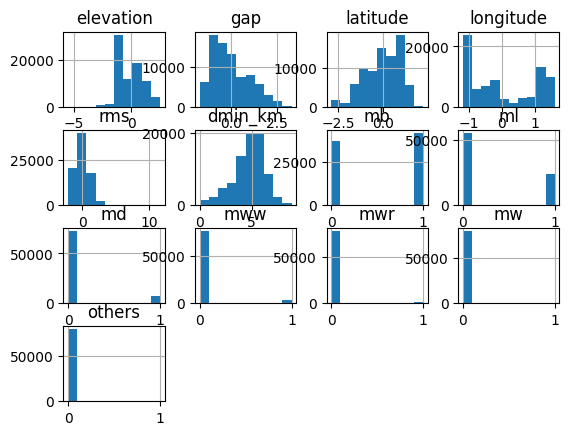

In [18]:
final_data[0].select_dtypes(include='number').hist()

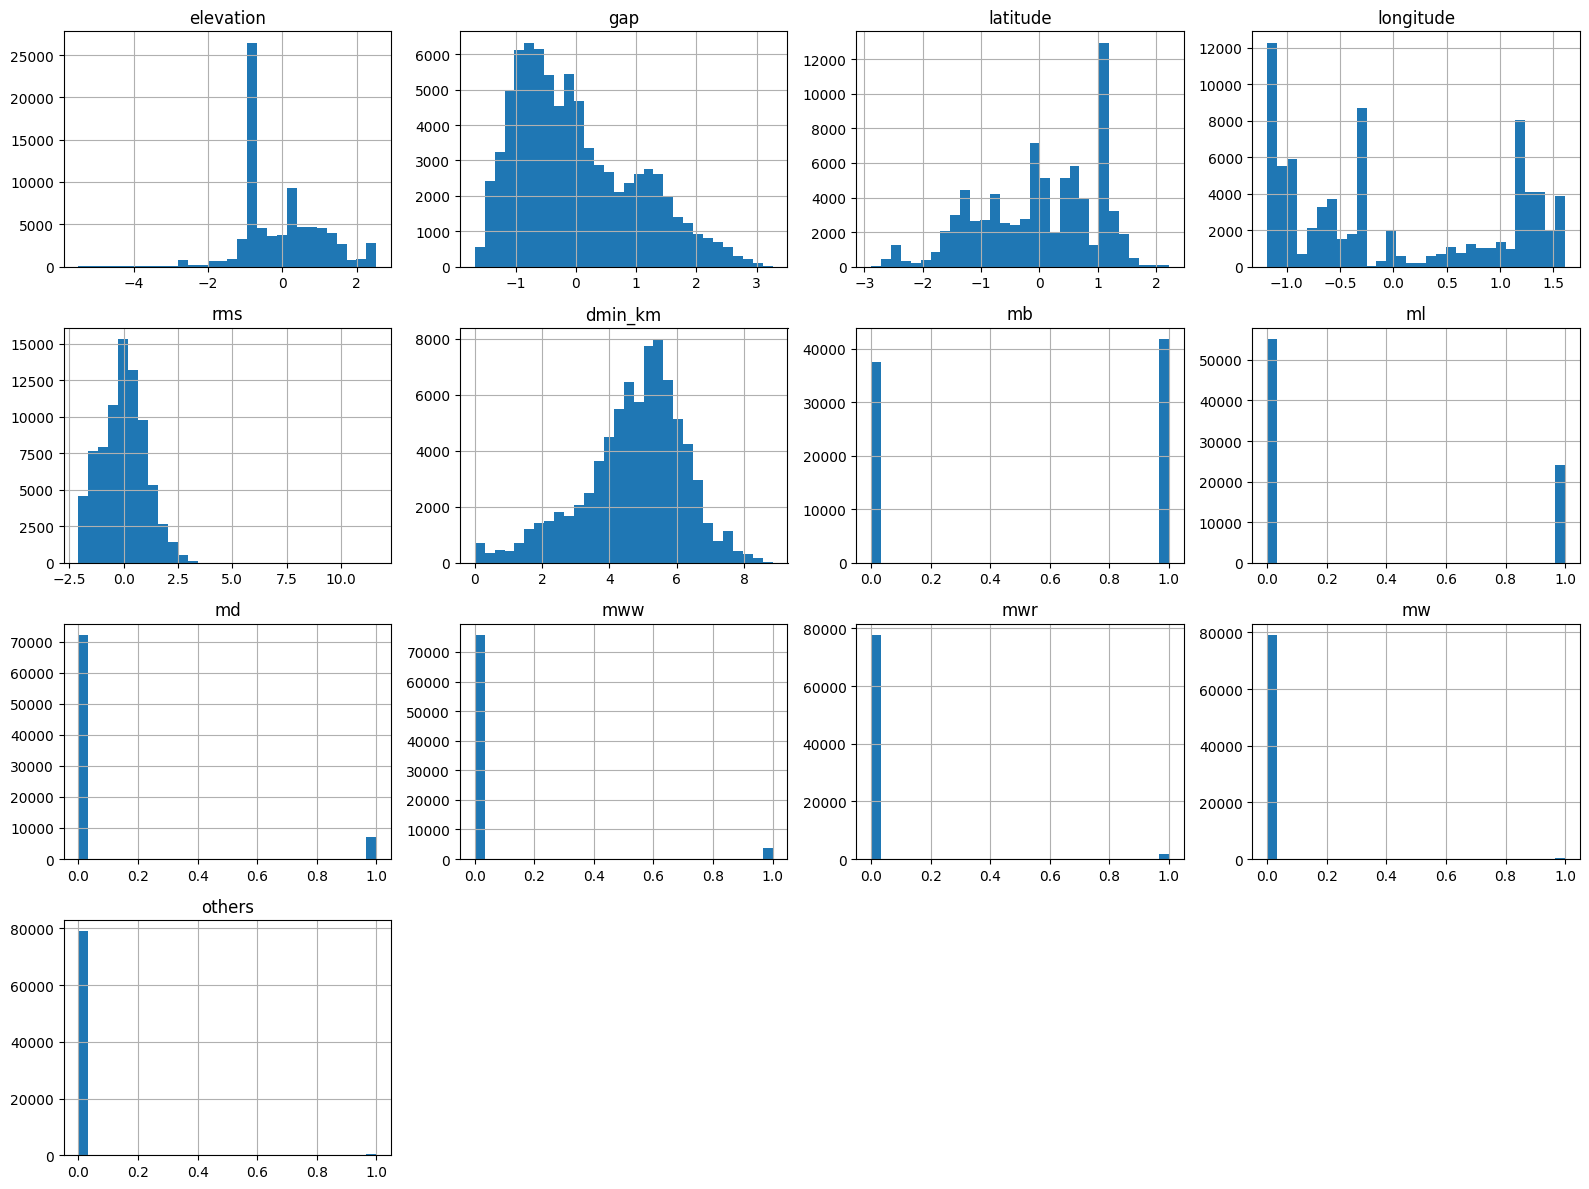

In [19]:
import matplotlib.pyplot as plt
import math

def plot_histograms_grid(df, cols=None, bins=30, figsize=(16, 12)):
    """
    Plots histograms for multiple numerical columns in a grid.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        cols (list or None): List of column names to plot. If None, plots all numerical columns.
        bins (int): Number of bins for the histograms.
        figsize (tuple): Size of the figure for the grid.
    """
    if cols is None:
        cols = df.select_dtypes(include='number').columns
    
    n_cols = len(cols)
    grid_size = math.ceil(math.sqrt(n_cols))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()

    for idx, col in enumerate(cols):
        df[col].hist(ax=axes[idx], bins=bins)
        axes[idx].set_title(col)
    # Hide any unused subplots
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_histograms_grid(final_data[0])

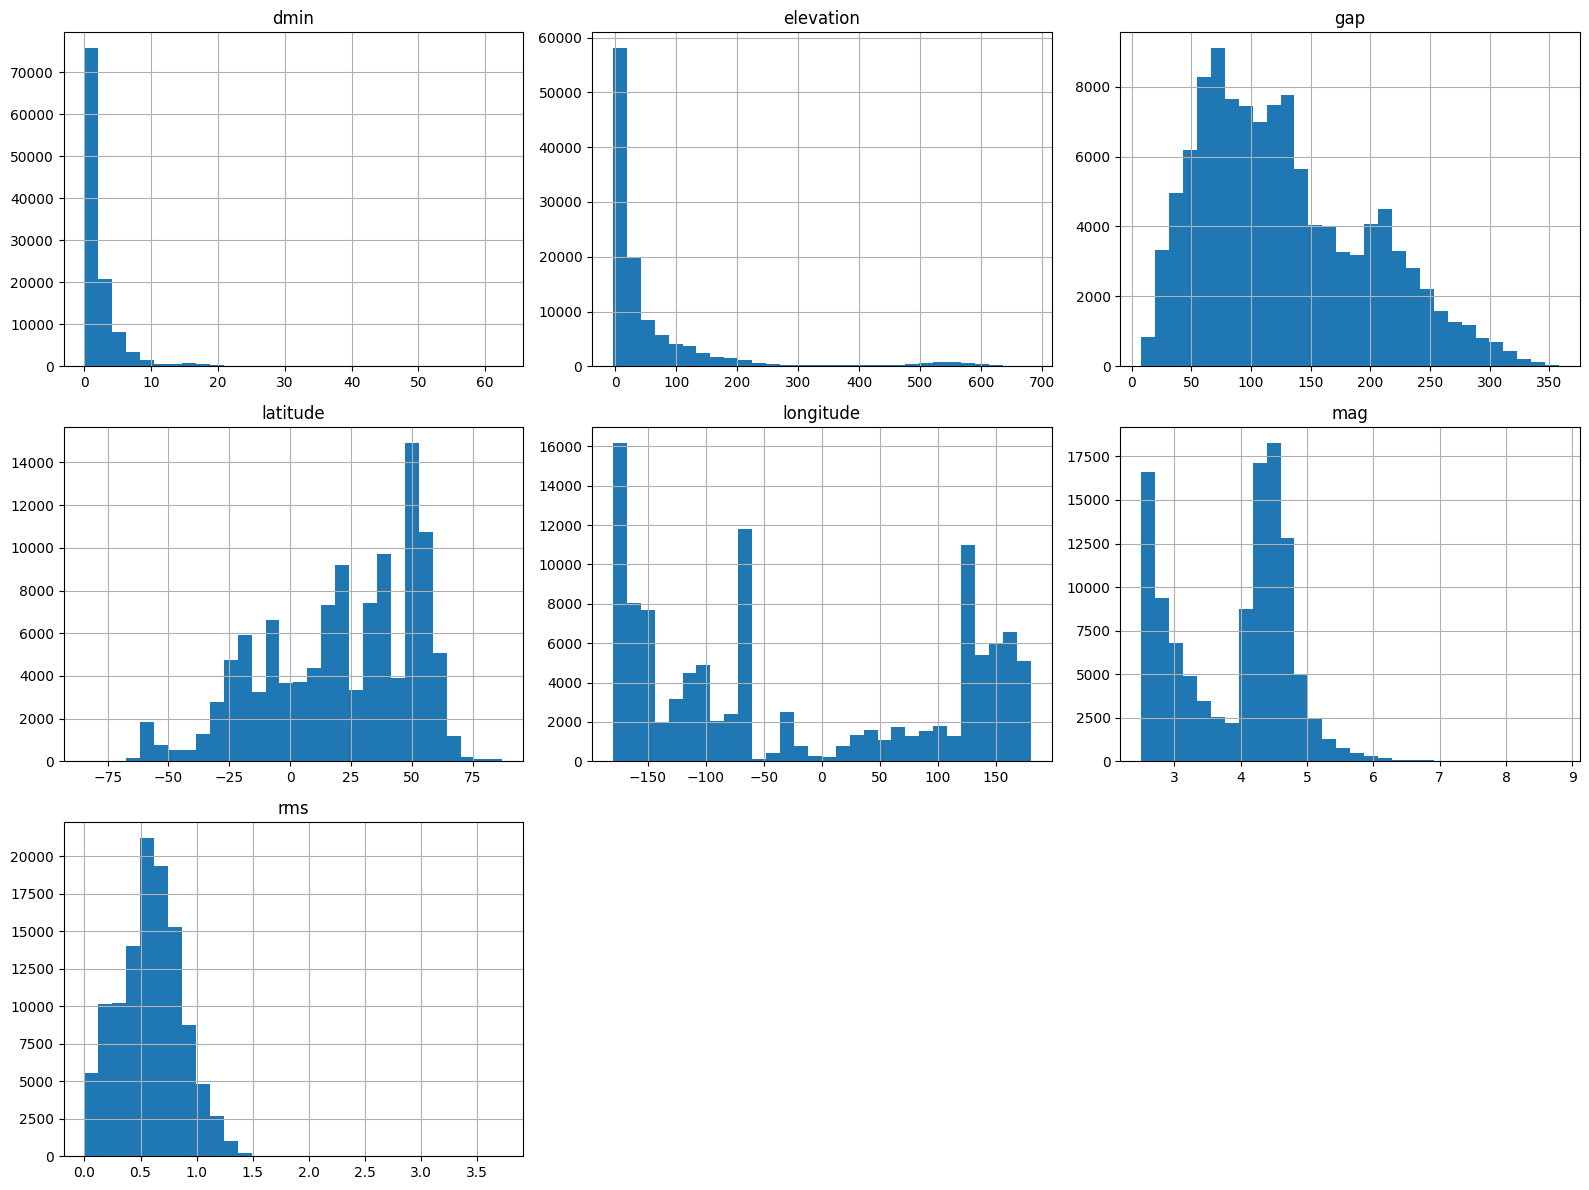

In [36]:
plot_histograms_grid(Xt)

In [20]:
final_data[1]

0        3.40
1        4.40
2        4.30
3        3.60
4        2.90
         ... 
79713    3.04
79714    2.50
79715    2.70
79716    4.40
79717    5.20
Name: mag, Length: 79374, dtype: float64

In [27]:
X_train, y_train = final_data[0].select_dtypes(include='number'), final_data[1]
X_train.shape, y_train.shape

((79374, 13), (79374,))

In [28]:
X_train

,elevation,gap,latitude,longitude,rms,dmin_km,mb,ml,md,mww,mwr,mw,others
0,-0.691600,1.811229,1.102288,-1.009014,-0.019172,5.570323,0,1,0,0,0,0,0
1,0.421279,0.680350,-1.627107,-1.168253,0.054318,5.302905,1,0,0,0,0,0,0
2,1.539229,-0.535345,-1.400917,-0.305234,1.119919,5.227050,1,0,0,0,0,0,0
3,-1.531469,-1.213873,0.495562,-0.412766,-0.827559,1.668912,0,0,0,0,0,1,0
4,1.575264,2.574573,1.095672,-1.134338,-0.386621,3.819627,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79369,-0.624994,1.429557,-0.010870,-0.304194,-1.121518,3.283264,0,0,1,0,0,0,0
79370,-0.349978,-0.874609,0.825469,-0.679864,-0.055917,3.520492,0,1,0,0,0,0,0
79371,1.476559,0.722758,1.082410,-1.172773,-1.121518,3.779820,0,1,0,0,0,0,0
79372,-0.691600,0.482446,-1.890736,1.609128,1.046430,5.416313,1,0,0,0,0,0,0


In [ ]:
from sklearn.linear_model import LinearRegression

X_val, y_val = DataFile(data=Xt)._load_final_data(valid='true', cols=Xt.select_dtypes(exclude='object').columns)

# Fit linear regression model to training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the validation data
y_pred = model.predict(X_val.select_dtypes(include='number'))

---

### Final compilation testing

In [1]:
# Final compilation for Testing
# ---

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.helpers.datapi import callDataFetcher
from src.preprocessing.data_preprocessing import drop_rate_new, EQDataLoader
from src.preprocessing.data_imputation_model import *

# ---

data = callDataFetcher(True)
valid_df = data[data['status'] == 'reviewed']
print(valid_df.columns)
print("\n", valid_df.shape)

# ---

print("OG data shape: ", data.shape)
c = drop_rate_new(valid_df)
print("Drop colummns: ", c)
c.remove('title')
c.remove('place')
c.remove('sources')
c.remove('geo')
print("\nDrop colummns: ", c)

# ---

filtered_df = valid_df.drop(columns=c)
t = filtered_df.copy()
EQDataLoader().coordinate_expander(t)

# ---

import pandas as pd
filt_df = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\engineered_data\New_Engineered_Data.csv")
filt_df.drop("Unnamed: 0", axis=1, inplace=True)
filt_df.rename(columns={"old_idx": "idx"}, inplace=True)
filt_df.set_index("idx", inplace=True)
fin_df = t.combine_first(filt_df).loc[t.index]
fin_df.drop(columns=['detail', 'geo', 'nst', 'time'], inplace=True)
fin_df['general_location'] = fin_df['place'].apply(lambda x : x.split(',')[-1])

# --- 

X = fin_df[['dmin', 'elevation', 'gap', 'latitude',	'longitude', 'mag',	'magType',	'rms']]
print(X.isna().sum(), "\n")

# ---

Index(['geo', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt',
       'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids',
       'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type',
       'title'],
      dtype='object')

 (113392, 27)
OG data shape:  (114220, 27)
Drop colummns:  ['tz', 'felt', 'cdi', 'mmi', 'alert', 'geo', 'place', 'url', 'alert', 'status', 'net', 'code', 'ids', 'sources', 'types', 'type', 'title', 'tsunami', 'updated', 'sig']

Drop colummns:  ['tz', 'felt', 'cdi', 'mmi', 'alert', 'url', 'alert', 'status', 'net', 'code', 'ids', 'types', 'type', 'tsunami', 'updated', 'sig']
Extracted coordinates for 113392 out of 113392 rows. Remaining rows contain NaN in new columns.
dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
rms             0
dtype: int64 



In [ ]:
"""Notebook-local clone of ``KNNImpute`` / ``ModelImputation`` for mixed-type DataFrames.

Only selected numeric columns are scaled and passed to ``KNNImputer``. The
``run_imputation_and_regression`` path matches ``data_imputation_model``: KNN on the
default seismic block, patch ``gap`` into the full frame (other columns unchanged),
then ``RidgeRegressionImputer`` for ``dmin``. ``impute_dataframe_numerical`` still merges
KNN outputs for arbitrary numeric column lists. The canonical module file is unchanged.
"""
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from types import SimpleNamespace

_root = Path.cwd().resolve()
for p in (_root, _root.parent):
    if (p / "src").is_dir() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src.preprocessing.data_preprocessing import Data_Sets

DEFAULT_IMPUTE_COLS = ["latitude", "longitude", "dmin", "gap", "rms"]


def resolve_numeric_impute_columns(
    df: pd.DataFrame,
    cols: list[str] | None = None,
) -> list[str]:
    """Return columns that exist, are numeric, and are not boolean."""

    def _ok(series: pd.Series) -> bool:
        return pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(
            series
        )

    if cols is None:
        want = [c for c in DEFAULT_IMPUTE_COLS if c in df.columns]
    else:
        want = [c for c in cols if c in df.columns]
    return [c for c in want if _ok(df[c])]


class ImputationStats:
    @staticmethod
    def calc_std(df_imp: pd.DataFrame, cols: list[str]) -> dict[str, float]:
        out: dict[str, float] = {}
        for c in cols:
            v = df_imp[c].std()
            if pd.isna(v) or v == 0:
                out[c] = 1.0
            else:
                out[c] = float(v)
        return out


class KNNImpute:
    """KNN imputation on a fixed list of numeric columns (from a mixed-type DataFrame)."""

    SEISMIC_COLS = frozenset(["latitude", "longitude", "dmin", "gap", "rms"])

    def __init__(self, data=None, num_neighbors: int = 5, cols: list[str] | None = None):
        self.k = num_neighbors
        self.cols = list(DEFAULT_IMPUTE_COLS) if cols is None else list(cols)
        self.df = data
        self.std_cache: dict[str, float] | None = None
        self.GEO_WEIGHT = 1.0
        self.OTHER_WEIGHT = 0.4
        self._impt = None

    def _is_seismic_block(self) -> bool:
        return frozenset(self.cols) == self.SEISMIC_COLS

    def ensure_std(self, df_imp: pd.DataFrame) -> dict[str, float]:
        if self.std_cache is None:
            self.std_cache = ImputationStats.calc_std(df_imp, self.cols)
        return self.std_cache

    def _scale_frame(self, df_imp: pd.DataFrame, stds: dict[str, float]) -> pd.DataFrame:
        parts: dict[str, pd.Series] = {}
        if self._is_seismic_block():
            lat_s, lon_s = stds["latitude"], stds["longitude"]
            rms_s, gap_s, dmin_s = stds["rms"], stds["gap"], stds["dmin"]
            parts["latitude"] = (df_imp["latitude"] / lat_s) * self.GEO_WEIGHT
            parts["longitude"] = (df_imp["longitude"] / lon_s) * self.GEO_WEIGHT
            parts["rms"] = (df_imp["rms"] / rms_s) * self.OTHER_WEIGHT
            parts["gap"] = (df_imp["gap"] / gap_s) * self.OTHER_WEIGHT
            parts["dmin"] = (df_imp["dmin"] / dmin_s) * self.OTHER_WEIGHT
            return pd.DataFrame(parts, index=df_imp.index)

        for c in self.cols:
            s = stds[c]
            w = (
                self.GEO_WEIGHT
                if c in ("latitude", "longitude")
                else self.OTHER_WEIGHT
            )
            parts[c] = (df_imp[c] / s) * w
        return pd.DataFrame(parts, index=df_imp.index)

    def _unscale_frame(
        self, df_scaled: pd.DataFrame, stds: dict[str, float]
    ) -> pd.DataFrame:
        out: dict[str, pd.Series] = {}
        if self._is_seismic_block():
            out["latitude"] = (
                df_scaled["latitude"] * stds["latitude"] / self.GEO_WEIGHT
            )
            out["longitude"] = (
                df_scaled["longitude"] * stds["longitude"] / self.GEO_WEIGHT
            )
            out["rms"] = df_scaled["rms"] * stds["rms"] / self.OTHER_WEIGHT
            out["gap"] = df_scaled["gap"] * stds["gap"] / self.OTHER_WEIGHT
            out["dmin"] = df_scaled["dmin"] * stds["dmin"] / self.OTHER_WEIGHT
            return pd.DataFrame(out, index=df_scaled.index)

        for c in self.cols:
            s = stds[c]
            w = (
                self.GEO_WEIGHT
                if c in ("latitude", "longitude")
                else self.OTHER_WEIGHT
            )
            out[c] = df_scaled[c] * s / w
        return pd.DataFrame(out, index=df_scaled.index)

    def _knn_fitputer(self, df: pd.DataFrame, weights: str = "distance") -> pd.DataFrame:
        df_imp = df[self.cols].copy()
        stds = self.ensure_std(df_imp)
        k_scaled = self._scale_frame(df_imp, stds)
        imputer = KNNImputer(n_neighbors=self.k, weights=weights)
        self._impt = imputer
        imputed_scaled = imputer.fit_transform(k_scaled)
        df_imputed_scaled = pd.DataFrame(
            imputed_scaled, columns=self.cols, index=k_scaled.index
        )
        return self._unscale_frame(df_imputed_scaled, stds)

    def _knn_transputer(self, df: pd.DataFrame, weights: str = "distance") -> pd.DataFrame:
        if self.df is None:
            raise ValueError("Reference dataframe ``self.df`` is required for transform.")
        df_imp = df[self.cols].copy()
        self.std_cache = ImputationStats.calc_std(self.df[self.cols].copy(), self.cols)
        stds = self.std_cache
        k_scaled = self._scale_frame(df_imp, stds)
        if self._impt is None:
            raise ValueError("Imputer is not fitted; call ``_knn_fitputer`` first.")
        imputed_scaled = self._impt.transform(k_scaled)
        df_imputed_scaled = pd.DataFrame(
            imputed_scaled, columns=self.cols, index=k_scaled.index
        )
        return self._unscale_frame(df_imputed_scaled, stds)


class RidgeRegressionImputer:
    """Clone of ``data_imputation_model.RidgeRegressionImputer`` (log-target Ridge for ``dmin``)."""

    def __init__(self, alpha=1.0):
        self.feature_cols = ["latitude", "longitude", "gap", "rms"]
        self.target_col = "dmin"
        self.model = Ridge(alpha=alpha)

    def fit(self, df_train):
        train_known = df_train[df_train[self.target_col].notna()]
        X_train = train_known[self.feature_cols].values
        y_train = train_known[self.target_col].values
        y_train_log = np.log(y_train + 1)
        self.model.fit(X_train, y_train_log)

    def impute(self, df_train):
        feature_cols = self.feature_cols
        target_col = self.target_col
        self.fit(df_train)
        train_known = df_train[df_train[target_col].notna()]
        df_test = df_train[df_train[target_col].isna()]
        train_missing_mask = df_train[target_col].isna()
        if train_missing_mask.any():
            X_miss = df_train.loc[train_missing_mask, feature_cols].values
            log_preds = self.model.predict(X_miss)
            df_train.loc[train_missing_mask, target_col] = np.exp(log_preds)
        test_missing_mask = df_test[target_col].isna()
        if test_missing_mask.any():
            X_miss = df_test.loc[test_missing_mask, feature_cols].values
            log_preds = self.model.predict(X_miss)
            df_test.loc[test_missing_mask, target_col] = np.exp(log_preds)
        return train_known, df_test


class ModelImputation:
    """Apply KNN imputation on numeric targets only; other columns/dtypes are preserved."""

    @staticmethod
    def _stratify_train_pred(
        df: pd.DataFrame, shuffle: bool = True
    ) -> tuple[pd.DataFrame, pd.DataFrame]:
        if "gap" in df.columns:
            train_df, pred_df = Data_Sets.stratify_split(df, shuffle=shuffle)
            train_df = train_df.drop(columns=["gap_missing"], errors="ignore")
            pred_df = pred_df.drop(columns=["gap_missing"], errors="ignore")
            return train_df, pred_df
        return train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            shuffle=shuffle,
        )

    def impute_dataframe_numerical(
        self,
        data: pd.DataFrame,
        cols: list[str] | None = None,
        num_neighbors: int = 5,
        shuffle: bool = True,
    ) -> pd.DataFrame:
        num_cols = resolve_numeric_impute_columns(data, cols)
        if not num_cols:
            return data.copy()

        full = data.copy()
        train_df, pred_df = self._stratify_train_pred(full, shuffle=shuffle)

        knn = KNNImpute(data=full, num_neighbors=num_neighbors, cols=num_cols)
        x_train_imp = knn._knn_fitputer(train_df)
        x_pred_imp = knn._knn_transputer(pred_df)

        out = full.copy()
        for c in num_cols:
            out.loc[x_train_imp.index, c] = x_train_imp[c].to_numpy()
            out.loc[x_pred_imp.index, c] = x_pred_imp[c].to_numpy()
        return out

    def run_imputation_and_regression(
        self,
        data=None,
        save=False,
        num_neighbors: int = 5,
        ridge_alpha: float = 1.0,
        shuffle: bool = True,
    ):
        """Same order as ``data_imputation_model.ModelImputation.run_imputation_and_regression``."""
        if data is None:
            raise ValueError("Notebook clone: pass ``data`` (e.g. ``fin_df``).")
        x_t = data.copy()
        train_df, pred_df = self._stratify_train_pred(x_t, shuffle=shuffle)

        knn_cols = resolve_numeric_impute_columns(x_t, cols=None)
        if not knn_cols:
            raise ValueError(
                "No KNN columns resolved; need numeric columns from DEFAULT_IMPUTE_COLS."
            )

        knn_imp = KNNImpute(data=x_t, num_neighbors=num_neighbors, cols=knn_cols)
        X_train_imp = knn_imp._knn_fitputer(train_df)
        X_valid_imp = knn_imp._knn_transputer(pred_df)

        final_filled = x_t.copy()
        if "gap" in knn_cols and "gap" in final_filled.columns:
            gap_df = pd.concat(
                [X_train_imp[["gap"]], X_valid_imp[["gap"]]], axis=0
            )
            final_filled["gap"] = final_filled["gap"].fillna(gap_df["gap"])

        need = {"latitude", "longitude", "gap", "rms", "dmin"}
        if not need <= set(final_filled.columns):
            raise ValueError(
                f"RidgeRegressionImputer needs all of {sorted(need)}; missing "
                f"{sorted(need - set(final_filled.columns))}."
            )

        patched_train, patched_test = RidgeRegressionImputer(
            alpha=ridge_alpha
        ).impute(final_filled)
        final_df = pd.concat([patched_train, patched_test], axis=0).sort_index()

        if save:
            out_dir = Path("data/engineered_data")
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / "FinalData.csv"
            final_df.to_csv(out_path, index=False)
            print(f"final_df saved to {out_path.resolve()}")

        re_data = SimpleNamespace(final_filled=final_filled)
        return {
            "re_data": re_data,
            "p_train": patched_train,
            "p_test": patched_test,
            "Final_df": final_df,
            "kNN_imp_train": X_train_imp,
            "kNN_imp_valid": X_valid_imp,
        }


def run_test_funcs(X):
    cols_default = resolve_numeric_impute_columns(X, cols=None)
    print("Default KNN (seismic) columns:", cols_default)

    model_imp = ModelImputation()
    pipe = model_imp.run_imputation_and_regression(data=X, save=False)
    Xt = pipe["Final_df"]
    print(
        "KNN gap-patch + Ridge dmin — gap NA:",
        int(Xt["gap"].isna().sum()),
        "dmin NA:",
        int(Xt["dmin"].isna().sum()),
    )

    try:
        from IPython.display import display
    except ImportError:
        display = print

    display(Xt.head())
    num_cols = [
        c
        for c in X.columns
        if pd.api.types.is_numeric_dtype(X[c])
        and not pd.api.types.is_bool_dtype(X[c])
    ]
    print("Missing counts after (numeric):", Xt[num_cols].isna().sum().to_dict())
    return Xt


Xt = run_test_funcs(X=fin_df)

Default KNN (seismic) columns: ['latitude', 'longitude', 'dmin', 'gap', 'rms']
KNN gap-patch + Ridge dmin — gap NA: 0 dmin NA: 0


,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title,general_location
0,2.35200,10.000,255.0,52.808600,-157.5767,3.4,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska
1,1.79800,44.780,175.0,-31.059400,-178.1009,4.4,mb,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region
2,1.66600,190.770,89.0,-24.109100,-66.8673,4.3,mb,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina
3,0.03873,2.750,41.0,34.165333,-80.7270,3.6,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina
4,0.40100,199.832,309.0,52.605300,-173.7296,2.9,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska


Missing counts after (numeric): {'dmin': 0, 'elevation': 0, 'gap': 0, 'latitude': 0, 'longitude': 0, 'mag': 0, 'rms': 0}


In [3]:
Xt

,dmin,elevation,gap,latitude,longitude,mag,magType,place,rms,sources,title,general_location
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska
...,...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,","M 2.6 - 60 km ENE of San Vicente, Mexico",Mexico
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,"51 km W of Petrolia, CA",0.27,",nc,us,","M 3.2 - 51 km W of Petrolia, CA",CA
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,"98 km N of Yakutat, Alaska",1.30,",ak,us,","M 2.9 - 98 km N of Yakutat, Alaska",Alaska
114218,0.50000,5.000,131.0,60.460000,-139.454000,2.70,ml,"102 km N of Yakutat, Alaska",0.80,",ak,","M 2.7 - 102 km N of Yakutat, Alaska",Alaska


In [5]:
Xt.select_dtypes(include='number').skew()

dmin         4.804962
elevation    3.321751
gap          0.631259
latitude    -0.556549
longitude    0.252844
mag         -0.141536
rms          0.181762
dtype: float64

In [23]:
Xt.columns

Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
       'place', 'rms', 'sources', 'title', 'general_location'],
      dtype='object')

In [24]:
enc_df = DataFile()._encoding(Xt)
enc_df

,dmin,elevation,gap,latitude,longitude,mag,place,rms,sources,title,general_location,mb,ml,md,mww,mwr,mw,mb_lg,others
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,south of Alaska,0.56,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska,0,1,0,0,0,0,0,0
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,Kermadec Islands region,0.58,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region,1,0,0,0,0,0,0,0
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,"57 km WNW of San Antonio de los Cobres, Argentina",0.87,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina,1,0,0,0,0,0,0,0
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,"6 km E of Elgin, South Carolina",0.34,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina,0,0,0,0,0,1,0,0
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,"Andreanof Islands, Aleutian Islands, Alaska",0.46,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,"60 km ENE of San Vicente, Mexico",0.48,",ci,us,","M 2.6 - 60 km ENE of San Vicente, Mexico",Mexico,0,1,0,0,0,0,0,0
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,"51 km W of Petrolia, CA",0.27,",nc,us,","M 3.2 - 51 km W of Petrolia, CA",CA,0,1,0,0,0,0,0,0
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,"98 km N of Yakutat, Alaska",1.30,",ak,us,","M 2.9 - 98 km N of Yakutat, Alaska",Alaska,0,1,0,0,0,0,0,0
114218,0.50000,5.000,131.0,60.460000,-139.454000,2.70,"102 km N of Yakutat, Alaska",0.80,",ak,","M 2.7 - 102 km N of Yakutat, Alaska",Alaska,0,1,0,0,0,0,0,0


In [25]:

# Spare manual Testing 
X_train_set, y_train_set = Data_Sets.split_dataset_xy(enc_df, validation_flag=False, test_flag=False)
X_valid_set, y_valid_set = Data_Sets.split_dataset_xy(enc_df, validation_flag=True, test_flag=False)

X_train_set.shape, y_train_set.shape, X_valid_set.shape, y_valid_set.shape


((79374, 18), (79374,), (17009, 18), (17009,))

In [26]:
X_train_set.select_dtypes(include='number').skew()

dmin          4.631244
elevation     3.215330
gap           0.684507
latitude     -0.472521
longitude     0.324603
rms           0.207053
mb           -0.110433
ml            0.848517
md            2.843936
mww           4.323729
mwr           6.638808
mw           15.907817
mb_lg        18.296921
others       20.420245
dtype: float64

In [28]:
X_valid_set.select_dtypes(include='number').skew()

dmin          5.113956
elevation     3.415411
gap           0.599381
latitude     -0.557489
longitude     0.169756
rms           0.100521
mb           -0.278904
ml            0.977292
md            3.297709
mww           3.973859
mwr           7.600879
mw           15.492972
mb_lg        15.961233
others       92.211712
dtype: float64

In [30]:
cols = ['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'rms']

In [29]:
import math
class ExperimentalDataPreprocessor:
    def __init__(self, dataframe: pd.DataFrame, custom_cols: bool = False):
        self.dataframe = dataframe
        self.c_cols = custom_cols

    def log_transform_cols(self, cols):
        for col in cols:
            if col in self.dataframe.columns:
                self.dataframe[col] = self.dataframe[col].apply(
                    lambda x: math.log(x + 1) if pd.notnull(x) and x > 0 else x
                )
        return self.dataframe

    def square_transform_cols(self, cols, sq=True):
        for col in cols:
            if col in self.dataframe.columns:
                if sq:
                    self.dataframe[col] = self.dataframe[col].apply(
                        lambda x: np.sqrt(x) if pd.notnull(x) and x > 0 else x
                    )
                else:
                    self.dataframe[col] = self.dataframe[col].apply(
                        lambda x: np.cbrt(x) if pd.notnull(x) and x != 0 else x
                    )
        return self.dataframe

    def data_transform(self, cols: list = None):
        # If using custom columns, validate input
        self.cols = cols if self.c_cols else None
        if self.c_cols and cols is None:
            raise ValueError("custom_cols is True, but no columns (`cols`) are specified for transformation.")

        # 'dmin' columns conversion
        if 'dmin' in self.dataframe.columns:
            self.dataframe['dmin_km'] = self.dataframe['dmin'].apply(lambda x: x * 111.19)
            self.dataframe = self.dataframe.drop('dmin', axis=1)
        elif 'dmin_km' in self.dataframe.columns:
            pass  # Already in km, do nothing
        else:
            raise KeyError("Neither 'dmin' nor 'dmin_km' column found in the dataframe.")
        

        cols = self.dataframe.select_dtypes(include='number').columns
        
        # Now handle transformations based on skewness
        # Compute skewness of numeric columns
        skewness = self.dataframe[cols].skew()
        # For each col, conditionally apply transformation
        for col in cols:
            if col not in self.dataframe.columns:
                continue
            sk = skewness[col]
            if sk > 1:
                self.dataframe[col] = self.dataframe[col].apply(
                    lambda x: math.log(x + 1) if pd.notnull(x) and x > 0 else x
                )
            elif 0.5 < sk <= 1:
                self.dataframe[col] = self.dataframe[col].apply(
                    lambda x: np.sqrt(x) if pd.notnull(x) and x > 0 else x
                )
            # If not, leave as is
        return self.dataframe

    def imput_data_transform(self, cols, transform=True, dmin_convert=True) -> pd.DataFrame:
        # 'dmin' columns conversion
        if dmin_convert:
            if 'dmin' not in self.dataframe.columns:
                raise KeyError("'dmin' column not found in the dataframe.")
            self.dataframe['dmin_km'] = self.dataframe['dmin'].apply(lambda x: x * 111.19)
            self.dataframe = self.dataframe.drop('dmin', axis=1)

        if transform:
            skewness = self.dataframe[cols].skew()
            for col in cols:
                if col not in self.dataframe.columns:
                    continue
                sk = skewness[col]
                if sk > 1:
                    self.dataframe[col] = self.dataframe[col].apply(
                        lambda x: math.log(x + 1) if pd.notnull(x) and x > 0 else x
                    )
                elif 0.5 < sk <= 1:
                    self.dataframe[col] = self.dataframe[col].apply(
                        lambda x: np.sqrt(x) if pd.notnull(x) and x > 0 else x
                    )
                # If not, leave as is
                
        return self.dataframe

In [32]:
# df = DataPreprocessor(X_set).data_transform(log_t=log_, square=sq)
df_train = ExperimentalDataPreprocessor(X_train_set, True).data_transform(cols=cols)
df_valid = ExperimentalDataPreprocessor(X_valid_set).data_transform(cols=cols)

In [33]:
df_train.select_dtypes(include='number').skew()

elevation     0.362276
gap           0.176827
latitude     -0.472521
longitude     0.324603
rms           0.207053
mb           -0.110433
ml            0.848517
md            2.843936
mww           4.323729
mwr           6.638808
mw           15.907817
mb_lg        18.296921
others       20.420245
dmin_km      -0.665257
dtype: float64

In [34]:
df_valid.select_dtypes(include='number').skew()

elevation     0.455253
gap           0.067057
latitude     -0.557489
longitude     0.169756
rms           0.100521
mb           -0.278904
ml            0.977292
md            3.297709
mww           3.973859
mwr           7.600879
mw           15.492972
mb_lg        15.961233
others       92.211712
dmin_km      -0.699389
dtype: float64

In [35]:
# Fit ZScoreStandard on training data
z_scorer = ZScoreStandard(df_train, cols=cols)

# Transform the training set
df_train_z = z_scorer.fit_standard_Z()

# Transform the validation set using the fitted parameters
df_val_z = z_scorer.transform_standard_Z(df_valid)

In [36]:
df_train_z.select_dtypes(include='number').skew()

elevation     0.362276
gap           0.176827
latitude     -0.472521
longitude     0.324603
rms           0.207053
mb           -0.110433
ml            0.848517
md            2.843936
mww           4.323729
mwr           6.638808
mw           15.907817
mb_lg        18.296921
others       20.420245
dmin_km      -0.665257
dtype: float64

In [13]:
df_train = DataFile()._encoding(df_train) # TODO: Run a prediction and check the outputs
df_train = df_train.reset_index(drop=True)

df_valid = DataFile()._encoding(df_valid) # TODO: Run a prediction and check the outputs
df_valid = df_valid.reset_index(drop=True)

In [14]:
df_train.select_dtypes(include='number').skew()

elevation     0.362276
gap           0.176827
latitude     -0.472521
longitude     0.324603
rms           0.207053
dmin_km      -0.665257
mb           -0.110433
ml            0.848517
md            2.843936
mww           4.323729
mwr           6.638808
mw           15.907817
others       13.572589
dtype: float64

In [15]:
df_valid.select_dtypes(include='number').skew()

elevation     0.455253
gap           0.067057
latitude     -0.557489
longitude     0.169756
rms           0.100521
dmin_km      -0.699389
mb           -0.278904
ml            0.977292
md            3.297709
mww           3.973859
mwr           7.600879
mw           15.492972
mb_lg        15.961233
others       92.211712
dtype: float64

In [22]:
df_valid['mb_lg'].value_counts()

mb_lg
0    16943
1       66
Name: count, dtype: int64

In [40]:
df_train_z.head(5)

,elevation,gap,latitude,longitude,place,rms,sources,title,general_location,mb,ml,md,mww,mwr,mw,mb_lg,others,dmin_km
0,-0.691600,1.636510,1.102288,-1.009014,south of Alaska,-0.019172,",us,ak,ak,",M 3.4 - south of Alaska,south of Alaska,0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,5.570323
1,0.421279,0.766565,-1.627107,-1.168253,Kermadec Islands region,0.054318,",us,",M 4.4 - Kermadec Islands region,Kermadec Islands region,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,5.302905
2,1.539229,-0.438286,-1.400917,-0.305234,"57 km WNW of San Antonio de los Cobres, Argentina",1.119919,",us,",M 4.3 - 57 km WNW of San Antonio de los Cobres...,Argentina,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,5.227050
3,-1.531469,-1.400591,0.495562,-0.412766,"6 km E of Elgin, South Carolina",-0.827559,",se,us,","M 3.6 - 6 km E of Elgin, South Carolina",South Carolina,0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,1.668912
4,1.575264,2.147587,1.095672,-1.134338,"Andreanof Islands, Aleutian Islands, Alaska",-0.386621,",ak,us,","M 2.9 - Andreanof Islands, Aleutian Islands, A...",Alaska,0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,3.819627


In [41]:
# from main_new import DataFile
# final_training_data = DataFile(data=Xt)._load_final_data(cols=Xt.select_dtypes(exclude='object').columns)
# final_validation_data = DataFile(data=Xt)._load_final_data(valid='true', cols=Xt.select_dtypes(exclude='object').columns)

X_train, y_train = df_train_z.select_dtypes(include='number').values, y_train_set.values
X_val, y_val = df_val_z.select_dtypes(include='number').values, y_valid_set.values
# ---

# Print skewness of all numerical columns in final_data[0]
print(df_train_z.select_dtypes(include='number').skew().to_dict())
print(df_val_z.select_dtypes(include='number').skew().to_dict())

{'elevation': 0.36227622379668084, 'gap': 0.17682685859401545, 'latitude': -0.47252054176064, 'longitude': 0.3246031732530087, 'rms': 0.2070531721027095, 'mb': -0.11043284671743667, 'ml': 0.8485169179227416, 'md': 2.8439359975323844, 'mww': 4.323728724714976, 'mwr': 6.638807606671346, 'mw': 15.907817155919703, 'mb_lg': 18.296921180733666, 'others': 20.420244881789525, 'dmin_km': -0.6652571669674411}
{'elevation': 0.4552532000711417, 'gap': 0.06705675945332648, 'latitude': -0.5574886264249641, 'longitude': 0.16975648900526094, 'rms': 0.10052127401211379, 'mb': -0.27890357876964655, 'ml': 0.9772923991367122, 'md': 3.2977089237553203, 'mww': 3.973859343738941, 'mwr': 7.600878612189683, 'mw': 15.492972024063908, 'mb_lg': 15.961232714661344, 'others': 92.21171196550351, 'dmin_km': -0.6993886490908691}


array([[-0.69160004,  1.63651028,  1.10228772, ...,  0.        ,
         0.        ,  5.570323  ],
       [ 0.42127895,  0.76656484, -1.6271069 , ...,  0.        ,
         0.        ,  5.30290493],
       [ 1.5392288 , -0.43828638, -1.4009168 , ...,  0.        ,
         0.        ,  5.2270498 ],
       ...,
       [ 1.47655931,  0.80241327,  1.08240988, ...,  0.        ,
         0.        ,  3.77981987],
       [-0.69160004,  0.59505658, -1.89073554, ...,  0.        ,
         0.        ,  5.41631305],
       [ 0.29918055, -1.03650793, -2.43976798, ...,  0.        ,
         0.        ,  6.48058279]])

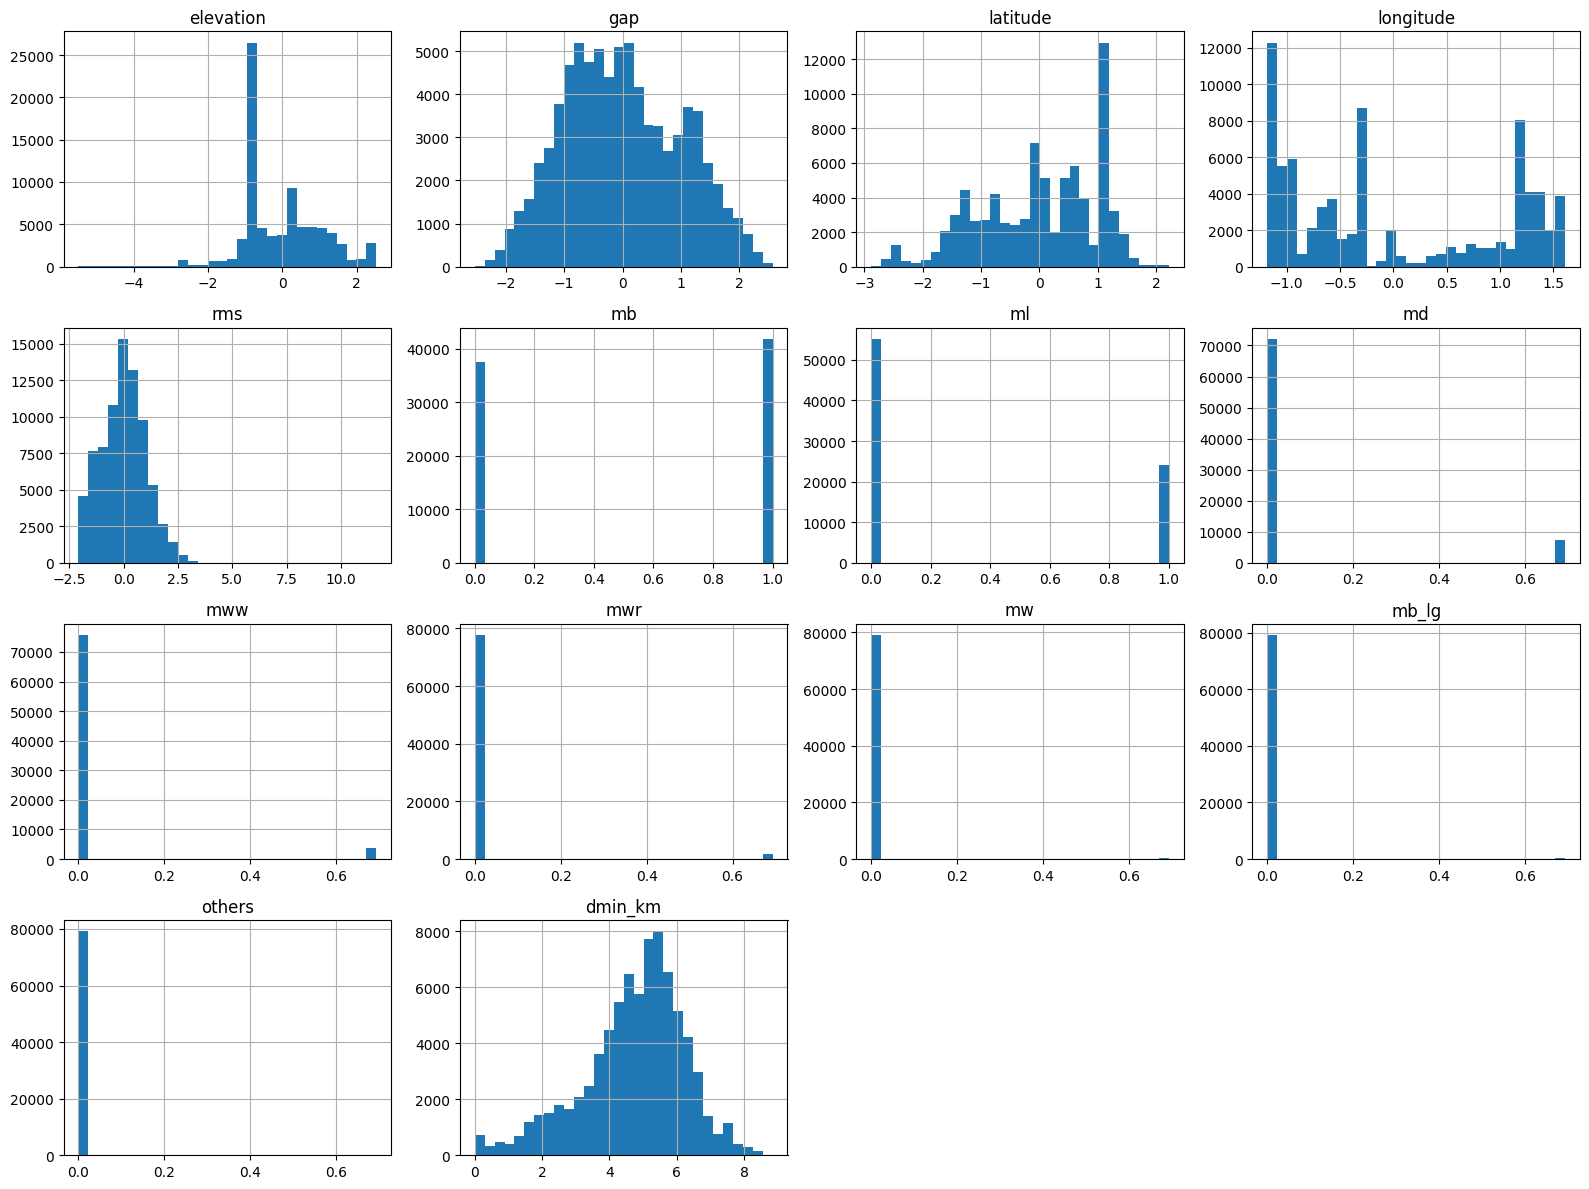

In [37]:
import matplotlib.pyplot as plt
import math

def plot_histograms_grid(df, cols=None, bins=30, figsize=(16, 12)):
    """
    Plots histograms for multiple numerical columns in a grid.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        cols (list or None): List of column names to plot. If None, plots all numerical columns.
        bins (int): Number of bins for the histograms.
        figsize (tuple): Size of the figure for the grid.
    """
    if cols is None:
        cols = df.select_dtypes(include='number').columns
    
    n_cols = len(cols)
    grid_size = math.ceil(math.sqrt(n_cols))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()

    for idx, col in enumerate(cols):
        df[col].hist(ax=axes[idx], bins=bins)
        axes[idx].set_title(col)
    # Hide any unused subplots
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_histograms_grid(df_train_z)

In [43]:
from sklearn.linear_model import LinearRegression

# Fit linear regression model to training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the validation data
y_pred = model.predict(X_val)

In [46]:
y_pred.max()

5.67979280848866